**Daniel Sanchez**

**CS460: Final Project**

**Swarm Behavior**

## Dataset Selection and Understanding

For this capstone project, I selected the **Swarm Behaviour** dataset. The Swarm Behaviour dataset focuses on modeling and predicting collective movement and coordination patterns of agents, such as animals, robots, or simulated swarm members.

The problem this dataset is trying to solve is a **behavior classification problem**. Each dataset is designed to classify whether a specific swarm behavior is present or not. The three related CSV files are **Aligned**, **Flocking**, and **Grouped**. Each file represents a separate binary classification task. The target variable is `Class`, where `1` represents the presence of the behavior and `0` represents the absence of the behavior.

The features represent numerical movement and interaction measurements for multiple swarm agents, also called boids. The main feature groups are:

- `x` and `y`: the X and Y position of an agent
- `xVel` and `yVel`: the velocity of an agent in the X and Y directions
- `xA` and `yA`: alignment-vector values
- `xS` and `yS`: separation-vector values
- `xC` and `yC`: cohesion-vector values
- `nAC`: number of nearby agents within the alignment/cohesion radius
- `nS`: number of nearby agents within the separation radius

These feature groups are repeated across multiple agents in the swarm, creating a high-dimensional dataset with **2,400 feature columns** and one binary target column named `Class`. Because the target variable contains two class labels, this project is treated as a **binary classification task**. The main objective is to train, tune, and compare machine learning models that can accurately classify swarm behavior from the agents’ movement, alignment, separation, and cohesion patterns. 


# Required libraries for the project

In [139]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import ast

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import confusion_matrix
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif

# Importing warning
import warnings

# Suppressing all warnings
warnings.filterwarnings("ignore")

# Uploading datasets for Swarm Behavior

In [96]:
# Loading the datasets into Google Colab via upload to session storage
aligned_df = pd.read_csv("Aligned.csv")
flocking_df = pd.read_csv("Flocking.csv")
grouped_df = pd.read_csv("Grouped.csv")

# Initial Raw Data Inspection Before Cleaning

In [97]:
# Checking raw datasets before cleaning

raw_datasets = {
    "Aligned": aligned_df,
    "Flocking": flocking_df,
    "Grouped": grouped_df
}
# This check includes: 
for dataset_name, df in raw_datasets.items():
    print(f"\n{dataset_name} raw dataset check")
    print("-" * 40)

    print("Shape:", df.shape)
    print("Last column name:", repr(df.columns[-1]))

    # Checking for extra whitespace in column names
    whitespace_columns = [column for column in df.columns if column != column.strip()]
    print("Columns with extra whitespace:", whitespace_columns)

    # Checking for true missing values in the raw file
    print("Raw missing values:", df.isnull().sum().sum())
    print("Raw rows with missing values:", df.isnull().any(axis=1).sum())

    # Checking for duplicate column names
    print("Duplicate columns:", df.columns.duplicated().sum())

    # Checking raw data types
    print("Data types:")
    print(df.dtypes.value_counts())

    # Checking for non-numeric or malformed values that would become NaN
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    malformed_values = numeric_df.isnull() & ~df.isnull()

    print("Malformed/non-numeric values:", malformed_values.sum().sum())
    print("Rows with malformed/non-numeric values:", malformed_values.any(axis=1).sum())

    # Showing the location and value of malformed entries, if any
    if malformed_values.sum().sum() > 0:
        bad_locations = malformed_values.stack()[malformed_values.stack()].index.tolist()

        print("Malformed value locations:")
        for row_index, column_name in bad_locations:
            print(
                f"Row {row_index}, Column {repr(column_name)}, "
                f"Value {repr(df.loc[row_index, column_name])}"
            )


Aligned raw dataset check
----------------------------------------
Shape: (24016, 2401)
Last column name: 'Class'
Columns with extra whitespace: []
Raw missing values: 0
Raw rows with missing values: 0
Duplicate columns: 0
Data types:
float64    2000
int64       401
Name: count, dtype: int64
Malformed/non-numeric values: 0
Rows with malformed/non-numeric values: 0

Flocking raw dataset check
----------------------------------------
Shape: (24016, 2401)
Last column name: 'Class '
Columns with extra whitespace: ['Class ']
Raw missing values: 0
Raw rows with missing values: 0
Duplicate columns: 0
Data types:
float64    1999
int64       401
object        1
Name: count, dtype: int64
Malformed/non-numeric values: 1
Rows with malformed/non-numeric values: 1
Malformed value locations:
Row 24015, Column 'x1', Value ' '

Grouped raw dataset check
----------------------------------------
Shape: (24016, 2401)
Last column name: 'Class'
Columns with extra whitespace: []
Raw missing values: 0
Raw ro

# Data Preprocessing

Done to the three datasets. Removing extra space, ensuring all values are numerical (datasets are already numeric but just incase something is odd within a dataset), looking for missing values, removing rows with missing values (not many missing, just 1), ensuring new row counts are stored, then printing before/after results for missing values and target names.
 - Flocking dataset contains one missing feature value in row 24015, column `x1`.
 - Flocking dataset target name has a extra space (removed the extra space)

In [98]:
# Removing any extra spaces from all column names
aligned_df.columns = aligned_df.columns.str.strip()
flocking_df.columns = flocking_df.columns.str.strip()
grouped_df.columns = grouped_df.columns.str.strip()

# Converting all values to numeric when possible
aligned_df = aligned_df.apply(pd.to_numeric, errors="coerce")
flocking_df = flocking_df.apply(pd.to_numeric, errors="coerce")
grouped_df = grouped_df.apply(pd.to_numeric, errors="coerce")

# Showing missing values before cleaning
print("Missing values before cleaning:")
print("Aligned:", aligned_df.isnull().sum().sum())
print("Flocking:", flocking_df.isnull().sum().sum())
print("Grouped:", grouped_df.isnull().sum().sum())

# Removing rows with missing values
aligned_df = aligned_df.dropna().reset_index(drop=True)
flocking_df = flocking_df.dropna().reset_index(drop=True)
grouped_df = grouped_df.dropna().reset_index(drop=True)

# Storing row counts after cleaning
aligned_rows_after = aligned_df.shape[0]
flocking_rows_after = flocking_df.shape[0]
grouped_rows_after = grouped_df.shape[0]

# Confirming the cleaning
print("\nMissing values after cleaning:")
print("Aligned:", aligned_df.isnull().sum().sum())
print("Flocking:", flocking_df.isnull().sum().sum())
print("Grouped:", grouped_df.isnull().sum().sum())

# Checking the target column names
print("\nTarget column names after cleaning:")
print("Aligned:", aligned_df.columns[-1])
print("Flocking:", flocking_df.columns[-1])
print("Grouped:", grouped_df.columns[-1])

Missing values before cleaning:
Aligned: 0
Flocking: 1
Grouped: 0

Missing values after cleaning:
Aligned: 0
Flocking: 0
Grouped: 0

Target column names after cleaning:
Aligned: Class
Flocking: Class
Grouped: Class


# Exploratory Data Analysis (EDA):

The shape of all three datasets after basic cleaning

In [99]:
# printing dataset shapes after cleaning
print("Dataset shapes after cleaning:")
print("Aligned:", aligned_df.shape)
print("Flocking:", flocking_df.shape)
print("Grouped:", grouped_df.shape)

Dataset shapes after cleaning:
Aligned: (24016, 2401)
Flocking: (24015, 2401)
Grouped: (24016, 2401)


Checking the first 5 rows of all three datasets

In [100]:
# Displaying the first 5 rows of each cleaned dataset
print("Aligned dataset:")
display(aligned_df.head())

print("Flocking dataset:")
display(flocking_df.head())

print("Grouped dataset:")
display(grouped_df.head())

Aligned dataset:


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
0,-1414.14,-535.22,-17.88,-7.23,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.85,0.0,0.00,0.0,0.0,0.00,0.00,29,0,0
1,-1412.93,597.54,-13.55,-5.48,0.00,0.0,0.00,0.00,0.00,0.00,...,-12.09,0.0,0.00,0.0,0.0,0.00,0.00,44,0,0
2,-1407.38,70.72,-14.37,-5.81,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.20,0.0,0.00,0.0,0.0,0.00,0.00,40,0,0
3,-1407.00,-759.80,-7.59,-1.27,-0.98,-0.2,0.00,0.00,0.91,0.41,...,2.99,-1.0,-0.07,0.0,0.0,-0.52,0.86,3,0,1
4,-1406.36,698.39,-16.54,-6.95,-1.00,0.0,-944.07,-396.62,0.00,0.00,...,-12.61,0.0,-1.00,0.0,0.0,0.00,0.00,13,0,0


Flocking dataset:


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
0,-1414.14,-535.22,-17.88,-7.23,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.85,0.0,0.00,0.0,0.0,0.00,0.00,29,0,0
1,-1412.93,597.54,-13.55,-5.48,0.00,0.0,0.00,0.00,0.00,0.00,...,-12.09,0.0,0.00,0.0,0.0,0.00,0.00,44,0,0
2,-1407.38,70.72,-14.37,-5.81,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.20,0.0,0.00,0.0,0.0,0.00,0.00,40,0,0
3,-1407.00,-759.80,-7.59,-1.27,-0.98,-0.2,0.00,0.00,0.91,0.41,...,2.99,-1.0,-0.07,0.0,0.0,-0.52,0.86,3,0,1
4,-1406.36,698.39,-16.54,-6.95,-1.00,0.0,-944.07,-396.62,0.00,0.00,...,-12.61,0.0,-1.00,0.0,0.0,0.00,0.00,13,0,0


Grouped dataset:


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
0,-1414.14,-535.22,-17.88,-7.23,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.85,0.0,0.00,0.0,0.0,0.00,0.00,29,0,0
1,-1412.93,597.54,-13.55,-5.48,0.00,0.0,0.00,0.00,0.00,0.00,...,-12.09,0.0,0.00,0.0,0.0,0.00,0.00,44,0,0
2,-1407.38,70.72,-14.37,-5.81,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.20,0.0,0.00,0.0,0.0,0.00,0.00,40,0,0
3,-1407.00,-759.80,-7.59,-1.27,-0.98,-0.2,0.00,0.00,0.91,0.41,...,2.99,-1.0,-0.07,0.0,0.0,-0.52,0.86,3,0,1
4,-1406.36,698.39,-16.54,-6.95,-1.00,0.0,-944.07,-396.62,0.00,0.00,...,-12.61,0.0,-1.00,0.0,0.0,0.00,0.00,13,0,0


Displaying general information on cleaned datasets: rows, columns, datatypes, and target.

In [101]:
# Displaying information for each cleaned dataset.
print("Aligned dataset info:")
aligned_df.info()

print("\nFlocking dataset info:")
flocking_df.info()

print("\nGrouped dataset info:")
grouped_df.info()

Aligned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24016 entries, 0 to 24015
Columns: 2401 entries, x1 to Class
dtypes: float64(2000), int64(401)
memory usage: 439.9 MB

Flocking dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24015 entries, 0 to 24014
Columns: 2401 entries, x1 to Class
dtypes: float64(2000), int64(401)
memory usage: 439.9 MB

Grouped dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24016 entries, 0 to 24015
Columns: 2401 entries, x1 to Class
dtypes: float64(2000), int64(401)
memory usage: 439.9 MB


Displaying summary statistics for all three data sets

In [102]:
# Displaying summary statistics for each cleaned dataset
print("Aligned dataset summary statistics:")
display(aligned_df.describe())

print("Flocking dataset summary statistics:")
display(flocking_df.describe())

print("Grouped dataset summary statistics:")
display(grouped_df.describe())

Aligned dataset summary statistics:


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
count,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,...,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.00000,24016.000000
mean,108.310513,-73.077114,-0.737331,0.041984,-0.148090,0.151028,-1.217209,-0.835799,-0.035581,0.075808,...,0.065710,-0.125927,0.127226,-1.660584,-0.095942,-0.017049,0.085548,26.258744,2.14736,0.312500
std,842.175333,572.552115,6.445250,7.374884,0.377028,0.590219,27.762943,21.669753,0.558147,0.626971,...,7.709457,0.380757,0.571121,77.201164,7.362780,0.551924,0.613370,33.997001,7.53273,0.463522
min,-1414.140000,-1012.180000,-18.590000,-18.410000,-1.000000,-1.000000,-944.070000,-847.910000,-2.680000,-2.680000,...,-18.440000,-1.040000,-1.000000,-4079.230000,-370.240000,-2.680000,-2.680000,0.000000,0.00000,0.000000
25%,-539.662500,-609.352500,-5.520000,-5.710000,-0.230000,-0.010000,0.000000,0.000000,-0.040000,-0.020000,...,-5.620000,-0.190000,0.000000,0.000000,0.000000,-0.072500,0.000000,2.000000,0.00000,0.000000
50%,156.085000,-156.685000,-0.460000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000
75%,898.112500,424.445000,3.820000,7.310000,0.000000,0.940000,0.000000,0.000000,0.000000,0.020000,...,7.480000,0.000000,0.540000,0.000000,0.000000,0.000000,0.020000,35.000000,1.00000,1.000000
max,1406.080000,1015.800000,18.470000,18.630000,1.000000,1.040000,68.560000,234.740000,2.680000,2.680000,...,18.530000,1.000000,1.040000,255.990000,68.940000,2.680000,2.680000,142.000000,65.00000,1.000000


Flocking dataset summary statistics:


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
count,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,...,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000,24015.000000
mean,108.280413,-73.075164,-0.737349,0.041626,-0.148095,0.150991,-1.217259,-0.835834,-0.035582,0.075811,...,0.065335,-0.125933,0.127189,-1.660653,-0.095946,-0.017050,0.085510,26.259338,2.147283,0.499979
std,842.179950,572.563956,6.445383,7.374829,0.377036,0.590203,27.763520,21.670204,0.558159,0.626984,...,7.709399,0.380764,0.571105,77.202771,7.362933,0.551935,0.613355,33.997584,7.532877,0.500010
min,-1414.140000,-1012.180000,-18.590000,-18.410000,-1.000000,-1.000000,-944.070000,-847.910000,-2.680000,-2.680000,...,-18.440000,-1.040000,-1.000000,-4079.230000,-370.240000,-2.680000,-2.680000,0.000000,0.000000,0.000000
25%,-539.665000,-609.365000,-5.520000,-5.710000,-0.230000,-0.010000,0.000000,0.000000,-0.040000,-0.020000,...,-5.620000,-0.190000,0.000000,0.000000,0.000000,-0.075000,0.000000,2.000000,0.000000,0.000000
50%,156.010000,-156.710000,-0.460000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000
75%,898.135000,424.460000,3.820000,7.310000,0.000000,0.940000,0.000000,0.000000,0.000000,0.020000,...,7.480000,0.000000,0.535000,0.000000,0.000000,0.000000,0.020000,35.000000,1.000000,1.000000
max,1406.080000,1015.800000,18.470000,18.630000,1.000000,1.040000,68.560000,234.740000,2.680000,2.680000,...,18.530000,1.000000,1.040000,255.990000,68.940000,2.680000,2.680000,142.000000,65.000000,1.000000


Grouped dataset summary statistics:


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
count,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,...,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.000000,24016.00000,24016.000000
mean,108.310513,-73.077114,-0.737331,0.041984,-0.148090,0.151028,-1.217209,-0.835799,-0.035581,0.075808,...,0.065710,-0.125927,0.127226,-1.660584,-0.095942,-0.017049,0.085548,26.258744,2.14736,0.375000
std,842.175333,572.552115,6.445250,7.374884,0.377028,0.590219,27.762943,21.669753,0.558147,0.626971,...,7.709457,0.380757,0.571121,77.201164,7.362780,0.551924,0.613370,33.997001,7.53273,0.484133
min,-1414.140000,-1012.180000,-18.590000,-18.410000,-1.000000,-1.000000,-944.070000,-847.910000,-2.680000,-2.680000,...,-18.440000,-1.040000,-1.000000,-4079.230000,-370.240000,-2.680000,-2.680000,0.000000,0.00000,0.000000
25%,-539.662500,-609.352500,-5.520000,-5.710000,-0.230000,-0.010000,0.000000,0.000000,-0.040000,-0.020000,...,-5.620000,-0.190000,0.000000,0.000000,0.000000,-0.072500,0.000000,2.000000,0.00000,0.000000
50%,156.085000,-156.685000,-0.460000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000
75%,898.112500,424.445000,3.820000,7.310000,0.000000,0.940000,0.000000,0.000000,0.000000,0.020000,...,7.480000,0.000000,0.540000,0.000000,0.000000,0.000000,0.020000,35.000000,1.00000,1.000000
max,1406.080000,1015.800000,18.470000,18.630000,1.000000,1.040000,68.560000,234.740000,2.680000,2.680000,...,18.530000,1.000000,1.040000,255.990000,68.940000,2.680000,2.680000,142.000000,65.00000,1.000000


Making a dictionary with approx 15 features, from each dataset, to analyze visually.
- Additionally, ensuring that the first 15 feature columns match across all three datasets, which they do. This allows for consistent visual analysis across the datasets using the same set of features.

In [103]:
# Store the cleaned datasets in a dictionary for repeated EDA steps
datasets = {
    "Aligned": aligned_df,
    "Flocking": flocking_df,
    "Grouped": grouped_df
}

# Get feature columns from each dataset by removing the target column
aligned_features = [column for column in aligned_df.columns if column != "Class"]
flocking_features = [column for column in flocking_df.columns if column != "Class"]
grouped_features = [column for column in grouped_df.columns if column != "Class"]

# Display the first 15 feature columns from each dataset
print("First 15 Aligned feature columns:")
print(aligned_features[:15])

print("\nFirst 15 Flocking feature columns:")
print(flocking_features[:15])

print("\nFirst 15 Grouped feature columns:")
print(grouped_features[:15])

# Check whether the first 15 feature columns match across all three datasets
same_first_15 = (
    aligned_features[:15] == flocking_features[:15] == grouped_features[:15]
)

print("\nDo the first 15 feature columns match across all datasets?")
print(same_first_15)

First 15 Aligned feature columns:
['x1', 'y1', 'xVel1', 'yVel1', 'xA1', 'yA1', 'xS1', 'yS1', 'xC1', 'yC1', 'nAC1', 'nS1', 'x2', 'y2', 'xVel2']

First 15 Flocking feature columns:
['x1', 'y1', 'xVel1', 'yVel1', 'xA1', 'yA1', 'xS1', 'yS1', 'xC1', 'yC1', 'nAC1', 'nS1', 'x2', 'y2', 'xVel2']

First 15 Grouped feature columns:
['x1', 'y1', 'xVel1', 'yVel1', 'xA1', 'yA1', 'xS1', 'yS1', 'xC1', 'yC1', 'nAC1', 'nS1', 'x2', 'y2', 'xVel2']

Do the first 15 feature columns match across all datasets?
True


In [104]:
# Select the first 15 shared feature columns across all three datasets
selected_features = [
    column for column in aligned_features
    if column in flocking_features and column in grouped_features
][:15]

# Display the selected EDA features
print("Selected EDA features:")
print(selected_features)

# Confirm the number of selected features
print("\nNumber of selected EDA features:", len(selected_features))

Selected EDA features:
['x1', 'y1', 'xVel1', 'yVel1', 'xA1', 'yA1', 'xS1', 'yS1', 'xC1', 'yC1', 'nAC1', 'nS1', 'x2', 'y2', 'xVel2']

Number of selected EDA features: 15


Class distribution plots
- The class distribution plots for the three datasets show that there is a significant imbalance in two of the datasets, with one class being much more prevalent than the other. 
- The Flocking dataset has a more balanced distribution between the two classes, while the Aligned and Grouped datasets are heavily skewed towards one class. 
- This imbalance could pose challenges for model training, as models may become biased towards the majority class. It may be necessary to consider techniques such Stratified train/test splits, Stratified cross validation, and utilizing F1 as a primary metric because Accuracy can be misleading in imblanced datasets. 

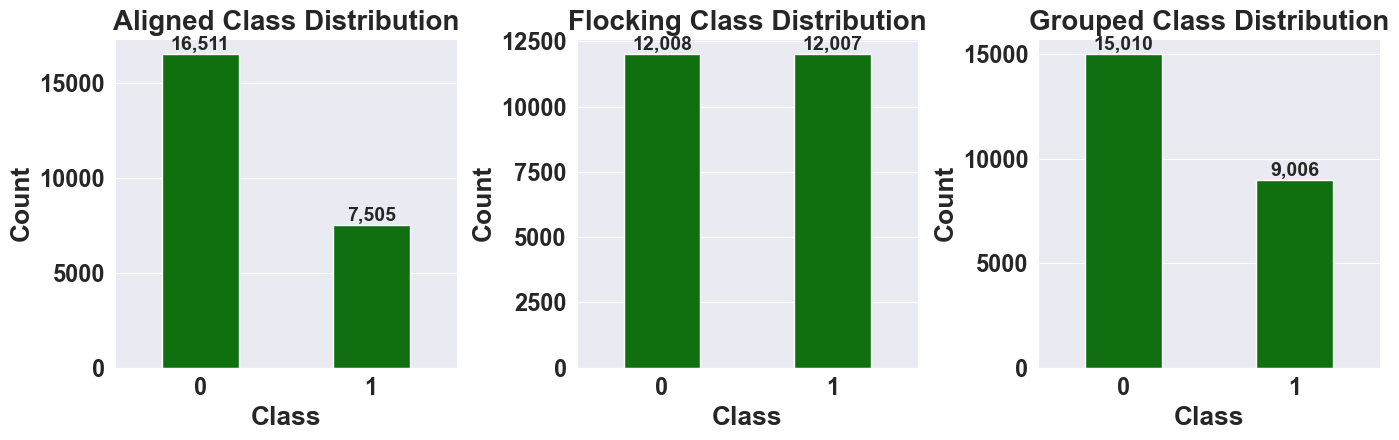

Aligned class counts:
Class
0    16511
1     7505
Name: count, dtype: int64

Flocking class counts:
Class
0    12008
1    12007
Name: count, dtype: int64

Grouped class counts:
Class
0    15010
1     9006
Name: count, dtype: int64



In [172]:
# Plotting class distributions for all datasets side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (dataset_name, df) in zip(axes, datasets.items()):

    sns.countplot(
        data=df,
        x="Class",
        ax=ax,
        color="green"
    )

    for bar in ax.patches:
        original_width = bar.get_width()
        new_width = 0.45
        bar.set_width(new_width)
        bar.set_x(bar.get_x() + (original_width - new_width) / 2)
        # labels on bars
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )
    # title and labels
    ax.set_title(
        f"{dataset_name} Class Distribution",
        fontsize=20,
        fontweight="bold"
    )
    ax.set_xlabel("Class", fontsize=19, fontweight="bold")
    ax.set_ylabel("Count", fontsize=19, fontweight="bold")

    ax.tick_params(axis="both", labelsize=17)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
# spacing and display
plt.tight_layout()
plt.show()

# Class counts for each dataset
for dataset_name, df in datasets.items():
    print(f"{dataset_name} class counts:")
    print(df["Class"].value_counts().sort_index())
    print()

Histogram
- The histograms for the selected features show that there is a wide range of values and distributions across the features, with some features exhibiting skewness or outliers. 
- This suggests that the data may have complex relationships and that certain features may be more informative for classification than others. The presence of skewed distributions and outliers also indicates that data preprocessing steps such as scaling may be necessary.

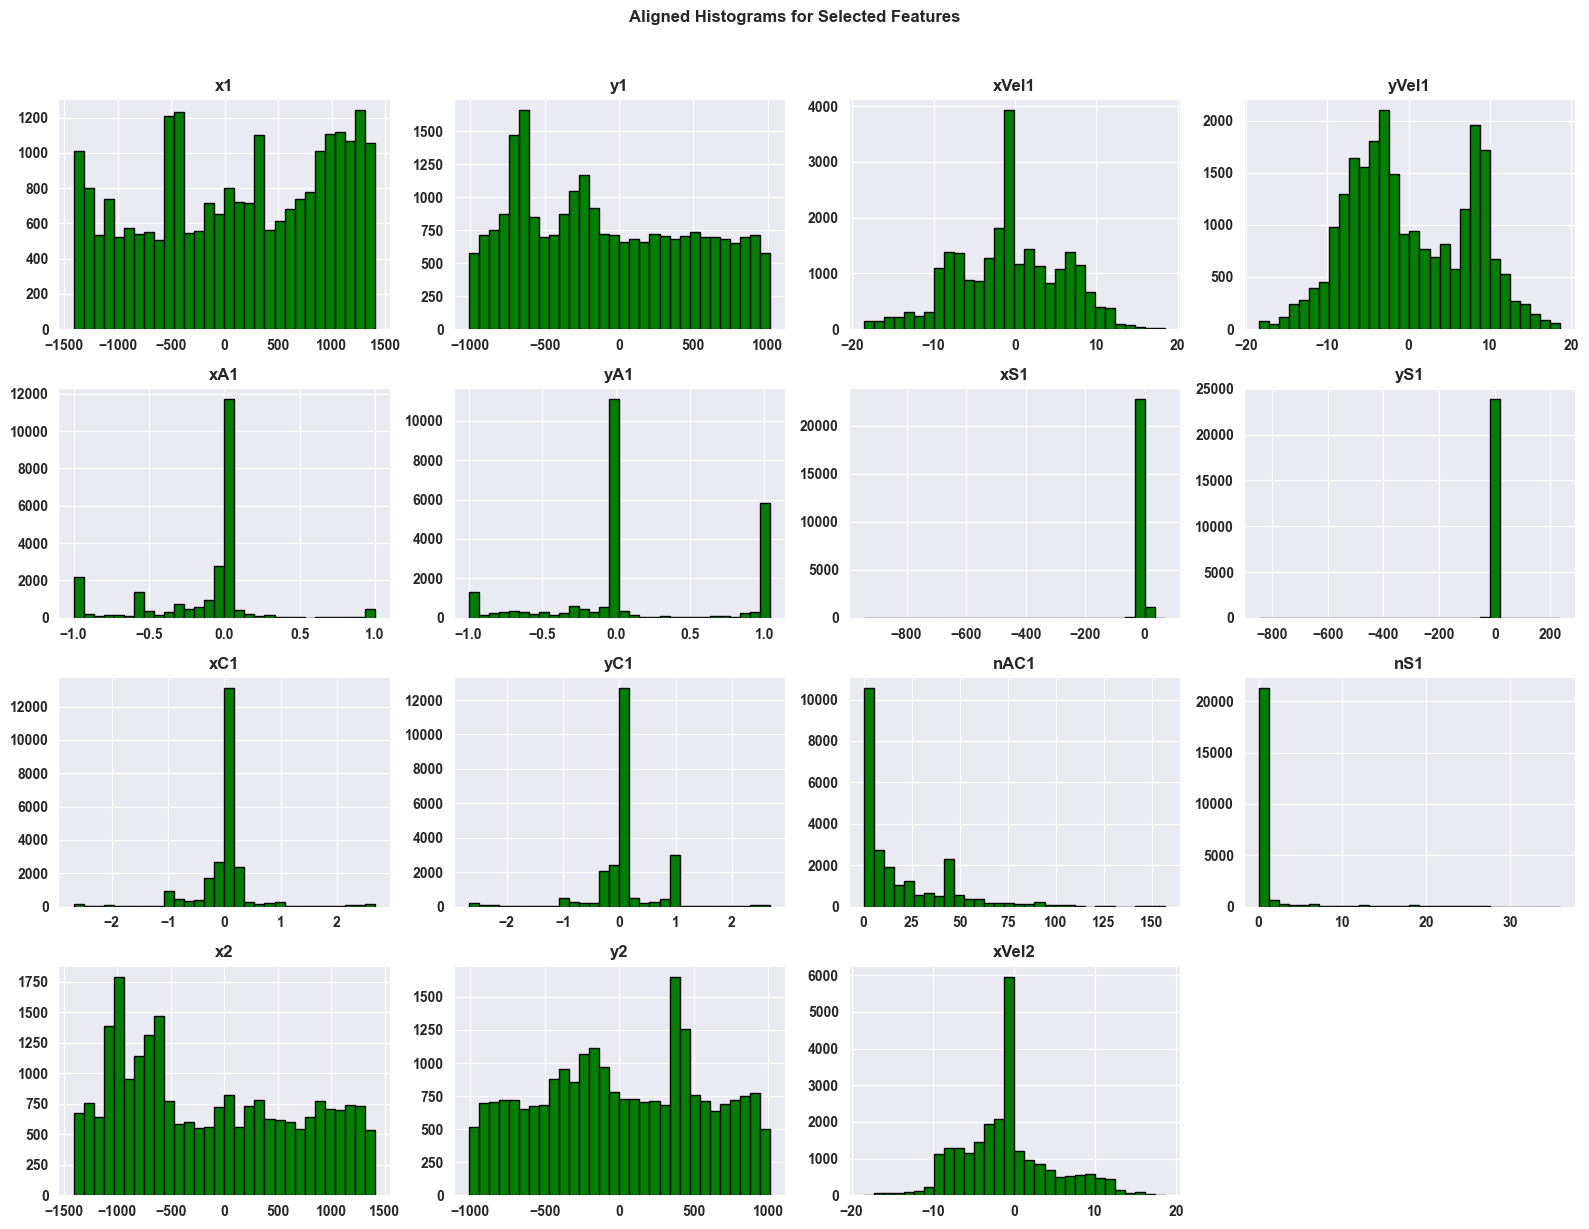

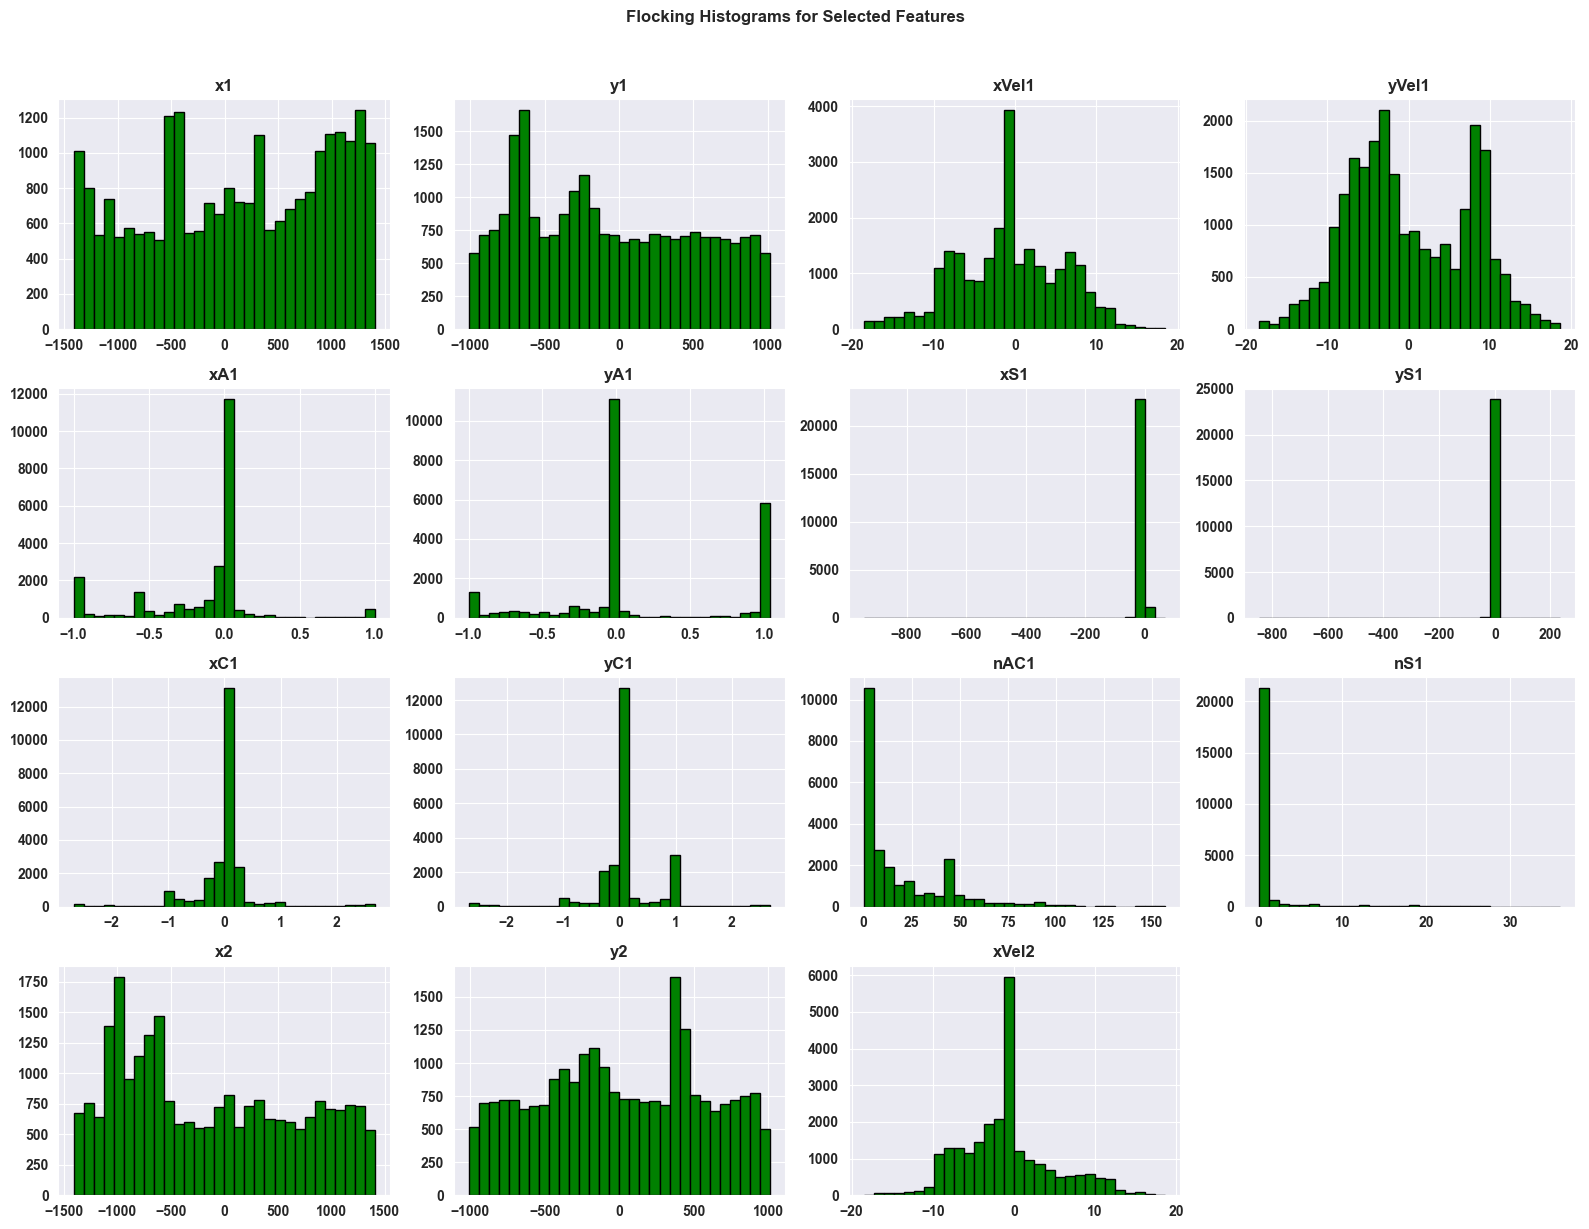

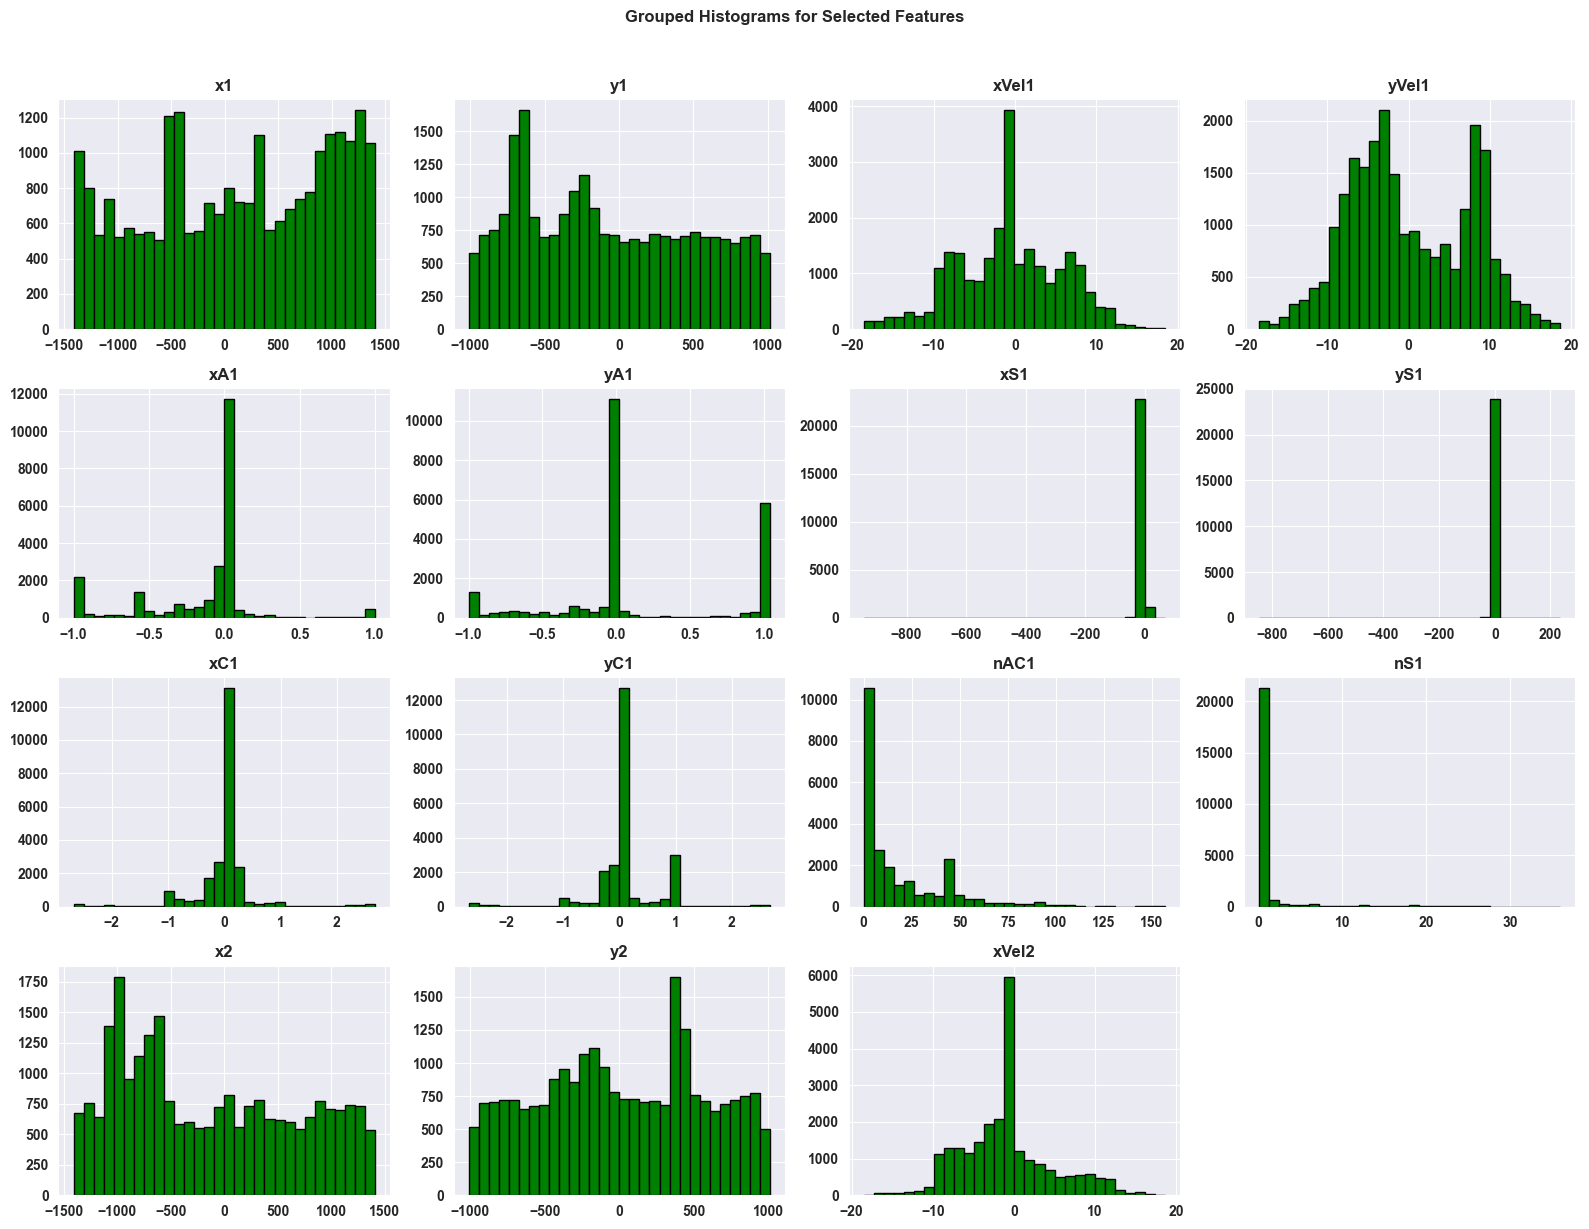

In [106]:
# Plotting histograms for selected features in each dataset
for dataset_name, df in datasets.items():

    # Creating histograms for the selected feature columns
    axes = df[selected_features].hist(
        figsize=(16, 12),
        bins=30,
        color="green",
        edgecolor="black"
    )

    # Making each histogram title and tick labels bold
    for ax in axes.flatten():
        ax.set_title(ax.get_title(), fontweight="bold")
        ax.set_xlabel(ax.get_xlabel(), fontweight="bold")
        ax.set_ylabel(ax.get_ylabel(), fontweight="bold")

        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

    # Adding a bold title for the full histogram grid
    plt.suptitle(
        f"{dataset_name} Histograms for Selected Features",
        y=1.02,
        fontweight="bold"
    )

    # Spacing between plots
    plt.tight_layout()

    # Displaying the histogram grid
    plt.show()

Outlier analysis utilizing IQR rule
- Across all three datasets, a significant number of features contain outliers based on the IQR rule.
- Out of 2,400 feature columns, 1,674 features contain at least one outlier, while 726 features contain no detected outliers.
- This suggests that the datasets includes many sparse or extreme movement-related values.

In [107]:
# Checking outliers across all feature columns using the IQR rule
outlier_summary_tables = {}
zero_outlier_summary = {}

for dataset_name, df in datasets.items():

    # Selecting all feature columns and exclude the target column
    feature_columns = [
        column for column in df.columns
        if column != "Class"
    ]

    # Storing outlier results for features that have at least one outlier
    outlier_results = []

    # Storing feature names that have zero outliers
    zero_outlier_features = []

    for feature in feature_columns:

        # Calculating the first quartile
        q1 = df[feature].quantile(0.25)

        # Calculating the third quartile
        q3 = df[feature].quantile(0.75)

        # Calculating the interquartile range
        iqr = q3 - q1

        # Calculating lower and upper IQR bounds
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Counting values outside the IQR bounds
        outlier_count = (
            (df[feature] < lower_bound) |
            (df[feature] > upper_bound)
        ).sum()

        # Calculating the percentage of rows flagged as outliers
        outlier_percent = (outlier_count / len(df)) * 100

        # Storing features with no outliers separately
        if outlier_count == 0:
            zero_outlier_features.append(feature)

        # Storing only features that have outliers
        else:
            outlier_results.append({
                "Feature": feature,
                "Outlier Count": outlier_count,
                "Outlier Percent": outlier_percent,
                "Lower Bound": lower_bound,
                "Upper Bound": upper_bound
            })

    # Converting outlier results to a DataFrame
    outlier_df = pd.DataFrame(outlier_results)

    # Sorting features by highest outlier percentage
    outlier_df = outlier_df.sort_values(
        by="Outlier Percent",
        ascending=False
    ).reset_index(drop=True)

    # Storing the outlier table for later use
    outlier_summary_tables[dataset_name] = outlier_df

    # Storing zero-outlier summary for the current dataset
    zero_outlier_summary[dataset_name] = {
        "Total Feature Count": len(feature_columns),
        "Features With Zero Outliers": len(zero_outlier_features),
        "Features With Outliers": len(outlier_df),
        "Zero Outlier Feature Names": zero_outlier_features
    }

    # Printing dataset-level summary
    print(f"{dataset_name} Outlier Summary")
    print("-" * 50)
    print("Total feature columns:", len(feature_columns))
    print("Features with zero outliers:", len(zero_outlier_features))
    print("Features with at least one outlier:", len(outlier_df))

    # Displaying only features that have outliers
    print("\nFeatures with outliers:")
    display(outlier_df)

    print("\n")

Aligned Outlier Summary
--------------------------------------------------
Total feature columns: 2400
Features with zero outliers: 726
Features with at least one outlier: 1674

Features with outliers:


,Feature,Outlier Count,Outlier Percent,Lower Bound,Upper Bound
0,yC84,11981,49.887575,0.000,0.000
1,xC43,11823,49.229680,0.000,0.000
2,yC104,11739,48.879913,0.000,0.000
3,yC4,11695,48.696702,0.000,0.000
4,xC147,11672,48.600933,0.000,0.000
...,...,...,...,...,...
1669,yA80,4,0.016656,-1.065,1.775
1670,yA132,3,0.012492,-1.110,1.850
1671,xVel109,3,0.012492,-19.035,18.045
1672,xVel178,2,0.008328,-21.830,18.170




Flocking Outlier Summary
--------------------------------------------------
Total feature columns: 2400
Features with zero outliers: 724
Features with at least one outlier: 1676

Features with outliers:


,Feature,Outlier Count,Outlier Percent,Lower Bound,Upper Bound
0,yC84,11981,49.889652,0.000,0.000
1,xC43,11822,49.227566,0.000,0.000
2,yC104,11738,48.877785,0.000,0.000
3,yC4,11694,48.694566,0.000,0.000
4,xC147,11672,48.602956,0.000,0.000
...,...,...,...,...,...
1671,xVel1,4,0.016656,-19.530,17.830
1672,yA132,3,0.012492,-1.110,1.850
1673,xVel109,3,0.012492,-19.035,18.045
1674,xVel178,2,0.008328,-21.830,18.170




Grouped Outlier Summary
--------------------------------------------------
Total feature columns: 2400
Features with zero outliers: 726
Features with at least one outlier: 1674

Features with outliers:


,Feature,Outlier Count,Outlier Percent,Lower Bound,Upper Bound
0,yC84,11981,49.887575,0.000,0.000
1,xC43,11823,49.229680,0.000,0.000
2,yC104,11739,48.879913,0.000,0.000
3,yC4,11695,48.696702,0.000,0.000
4,xC147,11672,48.600933,0.000,0.000
...,...,...,...,...,...
1669,yA80,4,0.016656,-1.065,1.775
1670,yA132,3,0.012492,-1.110,1.850
1671,xVel109,3,0.012492,-19.035,18.045
1672,xVel178,2,0.008328,-21.830,18.170


Correlation Heatmaps
 - The correlation heatmaps for the selected features show that there are strong correlations between a few features. 
 - There are also many features that do not show strong correlations with each other or with the target variable. 
  - The presence of both correlated and uncorrelated features suggests that dimensionality reduction techniques like PCA could be beneficial for this dataset, as they can help to capture the most important variance while reducing redundancy.

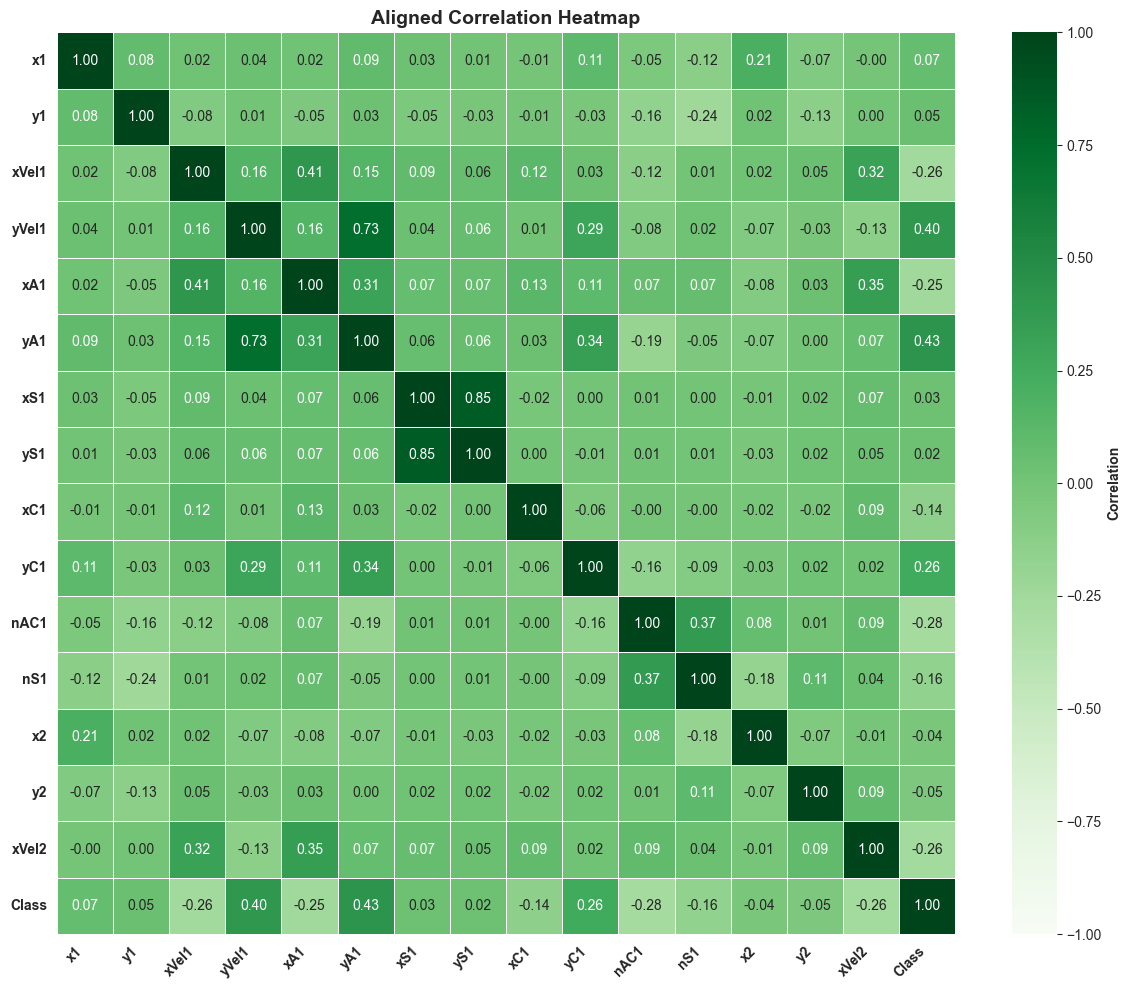

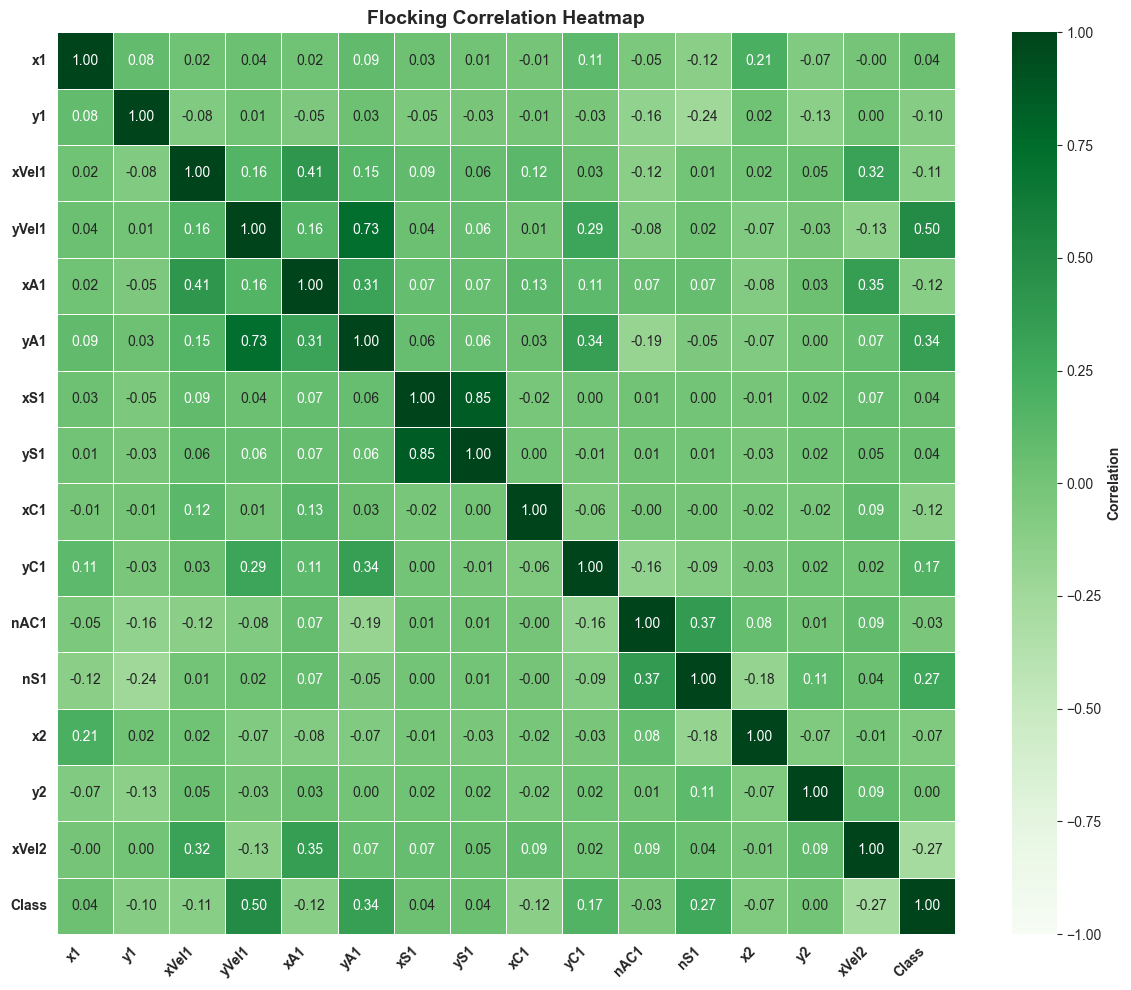

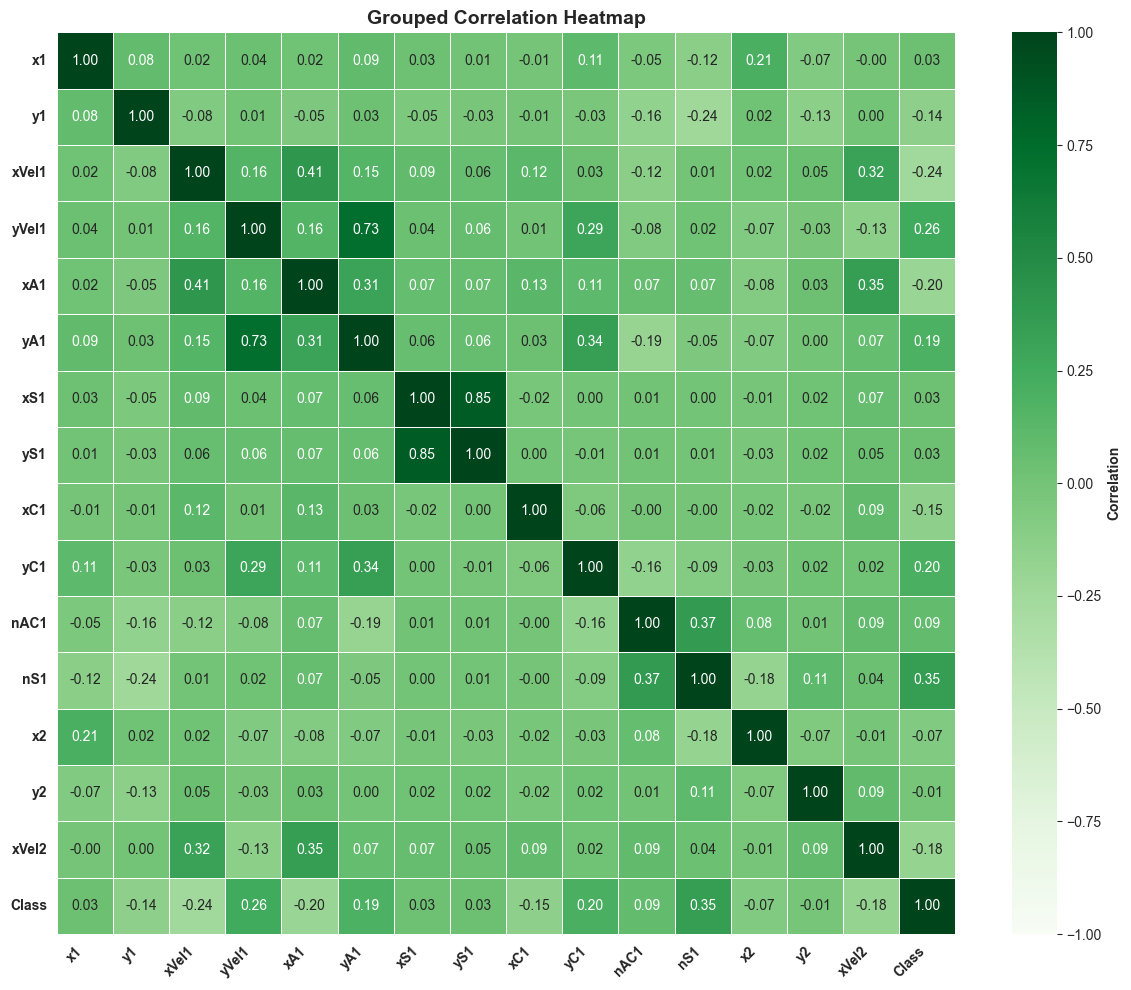

In [108]:
# Plotting correlation heatmaps for selected features and the target column
for dataset_name, df in datasets.items():

    # Combining selected features with the target column
    heatmap_columns = selected_features + ["Class"]

    # Calculating pairwise correlations for selected columns
    corr_matrix = df[heatmap_columns].corr()

    # Creating a figure for the current heatmap
    plt.figure(figsize=(12, 10))

    # Plotting the correlation matrix using green color shades
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Correlation"}
    )

    # Chart title
    plt.title(
        f"{dataset_name} Correlation Heatmap",
        fontweight="bold",
        fontsize=14
    )

    # x-axis tick labels
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        fontweight="bold"
    )

    # y-axis tick labels
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontweight="bold"
    )

    # bar label
    colorbar = ax.collections[0].colorbar
    colorbar.ax.yaxis.label.set_fontweight("bold")

    # spacing around labels
    plt.tight_layout()

    # Displaying the heatmap
    plt.show()

3D PCA visualization
 - Although the datasets are high dimensional. PCA Visualization results suggest lower-dimensional structure and strong class separability. 
 - The 3D PCA scatter plots show that Class 0 and Class 1 are visibly separated. 
 - The first three principal components explain about 30.63% of the total variance in each dataset.
 - Overall, this suggests that PCA may be helpful later for dimensionality reduction. 

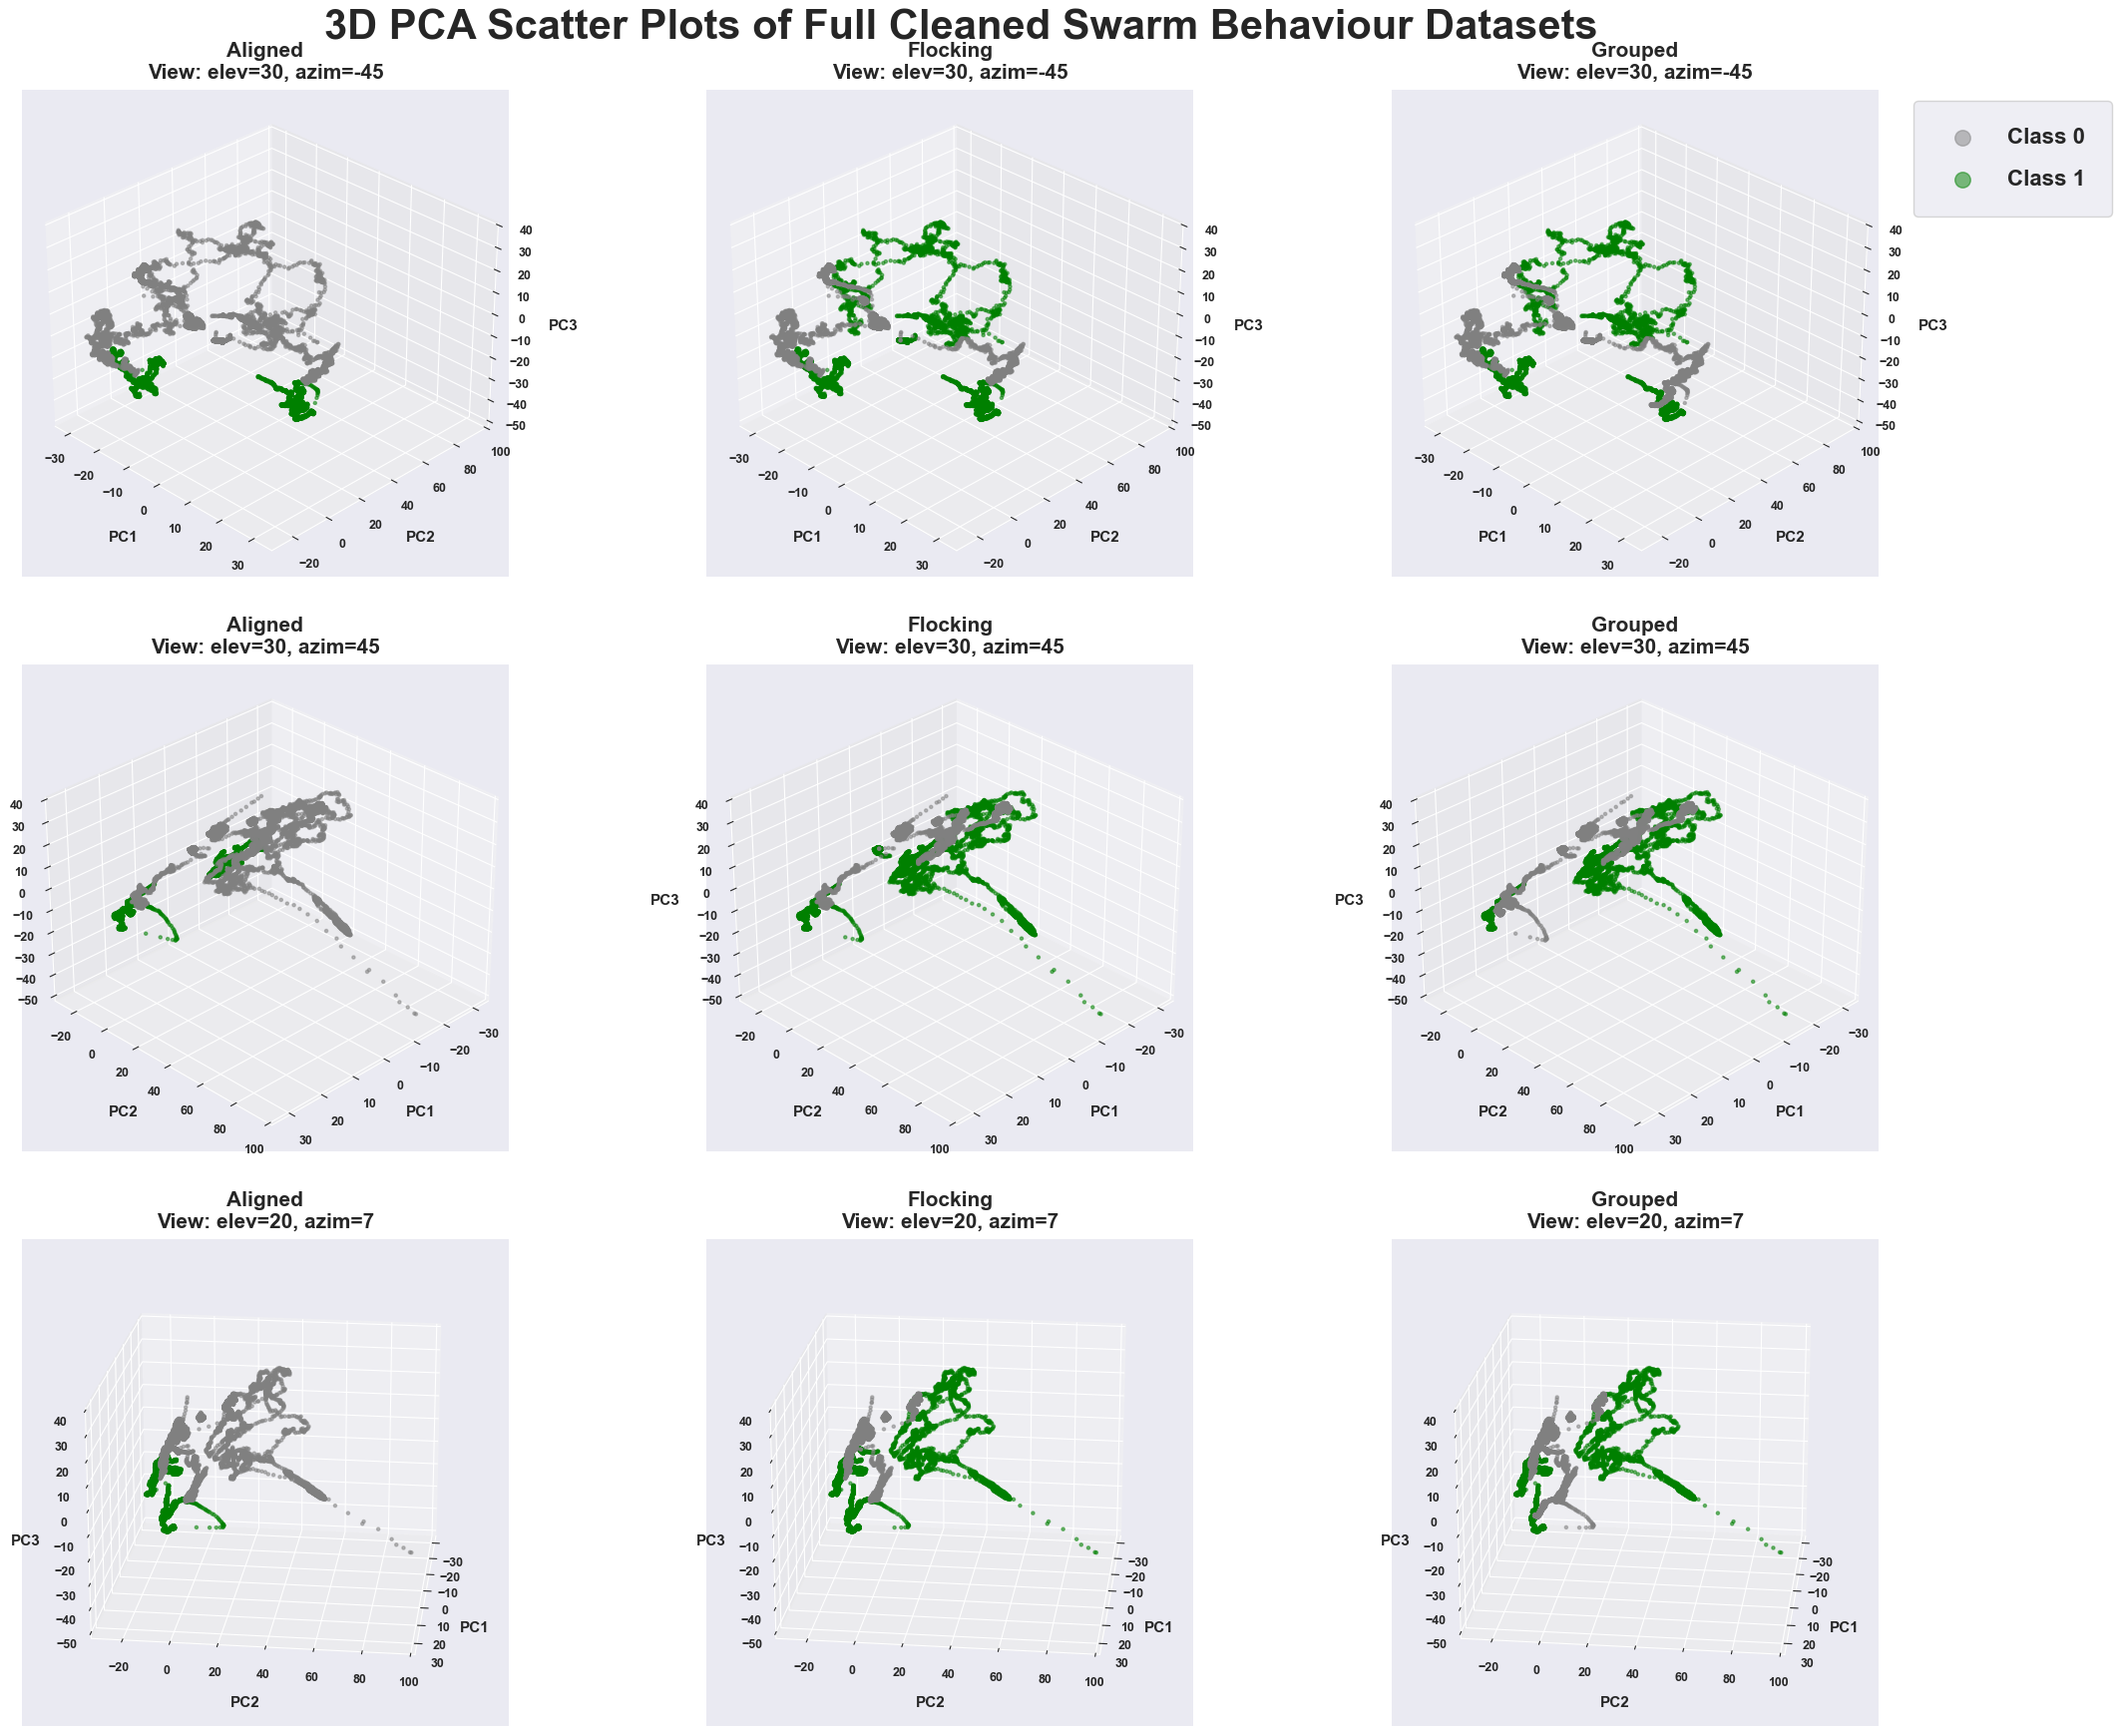

Aligned explained variance ratio:
[0.13915781 0.11315923 0.05395178]
Total explained variance by first 3 components: 0.3063

Flocking explained variance ratio:
[0.13915377 0.11316071 0.05395096]
Total explained variance by first 3 components: 0.3063

Grouped explained variance ratio:
[0.13915781 0.11315923 0.05395178]
Total explained variance by first 3 components: 0.3063



In [173]:
# Performing PCA on the full feature set of each dataset and plotting the first three principal components in 3D scatter plots

dataset_views = [
    ("Aligned", aligned_df),
    ("Flocking", flocking_df),
    ("Grouped", grouped_df)
]

# Defining multiple viewing angles to inspect the 3D PCA structure
view_angles = [
    (30, -45),
    (30, 45),
    (20, 7)
]

# Defining class colors for consistent plotting
class_colors = {
    0: "gray",
    1: "green"
}

# Storing PCA-transformed data for each dataset
pca_plot_data = {}

for dataset_name, df in dataset_views:

    # Separating predictor features and target labels
    X_full = df.drop(columns=["Class"])
    y_full = df["Class"]

    # Standardizing the full feature set before PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_full)

    # Reducing the standardized feature set to three principal components
    pca = PCA(n_components=3, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # Storing the PCA results in a DataFrame
    plot_df = pd.DataFrame(
        X_pca,
        columns=["PC1", "PC2", "PC3"]
    )

    plot_df["Class"] = y_full.values

    # Saving the transformed data for reuse across viewing angles
    pca_plot_data[dataset_name] = {
        "plot_df": plot_df,
        "explained_variance_ratio": pca.explained_variance_ratio_
    }

# Creating the full 3D PCA figure
fig = plt.figure(figsize=(22, 20))

for row_idx, (elev, azim) in enumerate(view_angles):
    for col_idx, (dataset_name, _) in enumerate(dataset_views):

        # Retrieving the stored PCA-transformed data
        plot_df = pca_plot_data[dataset_name]["plot_df"]

        # Creating one 3D subplot for the current dataset and viewing angle
        ax = fig.add_subplot(
            3,
            3,
            row_idx * 3 + col_idx + 1,
            projection="3d"
        )

        # Plotting each class separately for consistent colors and legend labels
        for class_value in sorted(plot_df["Class"].unique()):

            # Filtering the current class
            subset = plot_df[plot_df["Class"] == class_value]

            # Plotting the current class points
            ax.scatter(
                subset["PC1"],
                subset["PC2"],
                subset["PC3"],
                color=class_colors[class_value],
                label=f"Class {class_value}",
                alpha=0.5,
                s=5
            )

        # Setting the 3D viewing angle
        ax.view_init(
            elev=elev,
            azim=azim
        )

        # Adding subplot title
        ax.set_title(
            f"{dataset_name}\nView: elev={elev}, azim={azim}",
            fontsize=15,
            fontweight="bold",
            pad=8
        )

        # Adding bold axis labels
        ax.set_xlabel("PC1", fontsize=11, fontweight="bold", labelpad=8)
        ax.set_ylabel("PC2", fontsize=11, fontweight="bold", labelpad=8)
        ax.set_zlabel("PC3", fontsize=11, fontweight="bold", labelpad=8)

        # Making tick labels
        ax.tick_params(axis="both", labelsize=9)
        ax.tick_params(axis="z", labelsize=9)

        for tick_label in ax.get_xticklabels():
            tick_label.set_fontweight("bold")

        for tick_label in ax.get_yticklabels():
            tick_label.set_fontweight("bold")

        for tick_label in ax.get_zticklabels():
            tick_label.set_fontweight("bold")

        # Showing one legend only to reduce clutter
        # Make the legend
        if row_idx == 0 and col_idx == 2:
            legend = ax.legend(
                loc="upper left",
                bbox_to_anchor=(1.05, 1),
                fontsize=16,
                markerscale=5,
                frameon=True,
                borderpad=1.2,
                labelspacing=1.0,
                handletextpad=1.0
            )

            for text in legend.get_texts():
                text.set_fontweight("bold")

# main title
fig.suptitle(
    "3D PCA Scatter Plots of Full Cleaned Swarm Behaviour Datasets",
    fontsize=30,
    fontweight="bold",
    y=0.90
)

# Spacing between subplots
plt.subplots_adjust(
    left=0.03,
    right=0.96,
    bottom=0.04,
    top=0.86,
    wspace=0.02,
    hspace=0.18
)

# Displaying the full figure
plt.show()

# Printing explained variance ratios for each dataset
for dataset_name, _ in dataset_views:
    print(f"{dataset_name} explained variance ratio:")
    print(pca_plot_data[dataset_name]["explained_variance_ratio"])
    print(
        "Total explained variance by first 3 components:",
        round(pca_plot_data[dataset_name]["explained_variance_ratio"].sum(), 4)
    )
    print()

PCA Variance
- Creating data for variance plot


In [110]:
# Calculating and plot full PCA variance using fixed component counts

# Defining fixed PCA component counts from 25 to 2400
component_counts = list(range(25, 2401, 25))

# Storing PCA variance results
pca_variance_results = []

for dataset_name, df in datasets.items():

    # Separating features from the target column
    X = df.drop(columns=["Class"])

    # Standardizing features before PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Setting the maximum number of PCA components needed
    max_components = min(
        max(component_counts),
        X_scaled.shape[1],
        X_scaled.shape[0]
    )

    # Fitting PCA using all available feature components
    pca = PCA(
        n_components=max_components,
        svd_solver="full"
    )

    # Fitting PCA to the standardized data
    pca.fit(X_scaled)

    # Calculating cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Storing explained variance for each fixed component count
    for n_components in component_counts:

        # Skipping component counts larger than the fitted PCA space
        if n_components > max_components:
            continue

        # Storing the cumulative explained variance at this component count
        pca_variance_results.append({
            "Dataset": dataset_name,
            "PCA Components": n_components,
            "Cumulative Explained Variance": cumulative_variance[n_components - 1]
        })

# Converting PCA variance results to a DataFrame
pca_variance_df = pd.DataFrame(pca_variance_results)

PCA curves
- The PCA cumulative variance curves show that the Swarm Behaviour datasets are high-dimensional
- The overlapping curves also show that the datasets have very similar feature-variance structure.

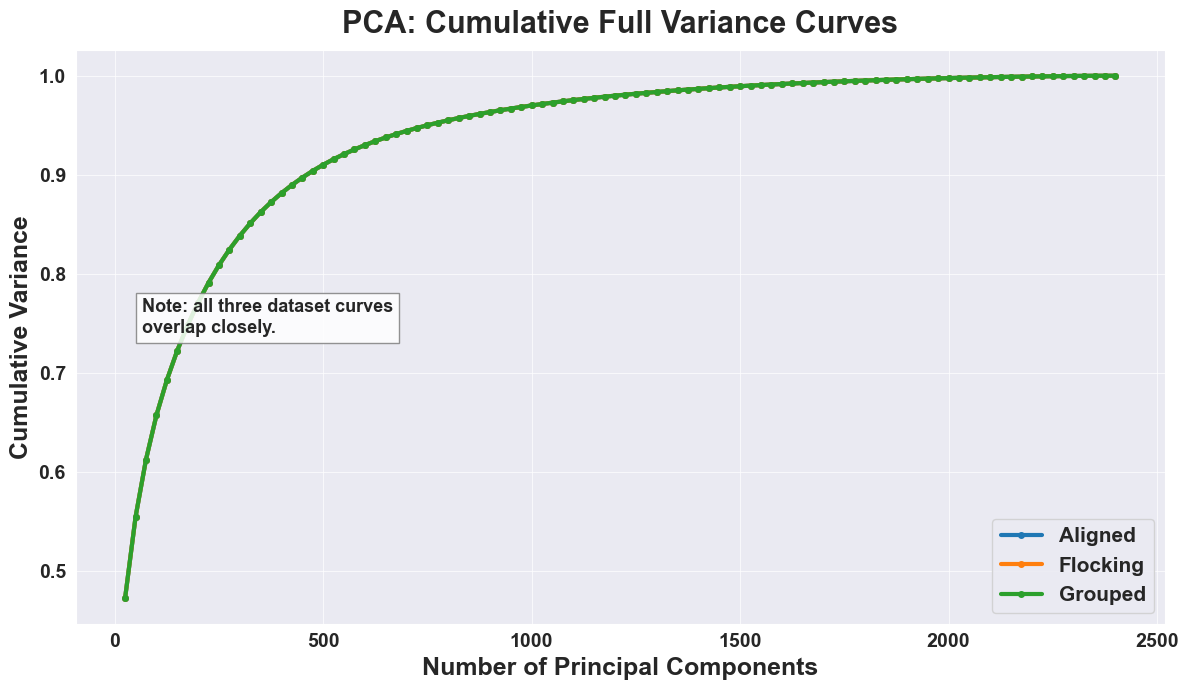

In [111]:
# Plotting PCA cumulative explained variance curves
plt.figure(figsize=(12, 7))

for dataset_name in pca_variance_df["Dataset"].unique():

    # Filtering results for the current dataset
    dataset_results = pca_variance_df[
        pca_variance_df["Dataset"] == dataset_name
    ]

    # Plotting cumulative explained variance by PCA component count
    plt.plot(
        dataset_results["PCA Components"],
        dataset_results["Cumulative Explained Variance"],
        marker="o",
        markersize=4,
        linewidth=3,
        label=dataset_name
    )

# chart title
plt.title(
    "PCA: Cumulative Full Variance Curves",
    fontweight="bold",
    fontsize=22,
    pad=12
)

# axis labels
plt.xlabel(
    "Number of Principal Components",
    fontweight="bold",
    fontsize=18
)

# y-axis label
plt.ylabel(
    "Cumulative Variance",
    fontweight="bold",
    fontsize=18
)

# tick labels
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

# grid lines
plt.grid(True, alpha=0.7)

# in-chart note explaining the overlapping curves
plt.text(
    65,
    0.74,
    "Note: all three dataset curves\noverlap closely.",
    fontsize=13,
    fontweight="bold",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.85
    )
)

# legend
legend = plt.legend(
    fontsize=15,
    loc="lower right",
    frameon=True
)

for text in legend.get_texts():
    text.set_fontweight("bold")

# spacing and display
plt.tight_layout()
plt.show()

Advanced EDA: PCA-Component Analysis
- Used to evaluate whether reduced PCA spaces preserved class-separating signal. 
- The strongest results occurred around higher component counts. 
- The result support the broader EDA findings. That the data is highly separable. 


In [113]:
# This is used as advanced EDA only. It is not final model tuning.
# The best-performing component counts in this diagnostic are not directly used
# as final model PCA hyperparameters.

# Defining PCA component counts to test
pca_component_grid = list(range(25, 201, 25))

# Defining stratified cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Storing results
pca_component_results = []

for dataset_name, df in datasets.items():
    X = df.drop(columns=["Class"])
    y = df["Class"]

    for n_components in pca_component_grid:
        print(f"{dataset_name}: PCA components = {n_components}")

        model = make_pipeline(
            StandardScaler(),
            PCA(n_components=n_components, svd_solver="randomized", random_state=42),
            LinearSVC(C=1.0, max_iter=10000, dual=False, random_state=42)
        )

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="f1",
            n_jobs=1
        )

        pca_component_results.append({
            "Dataset": dataset_name,
            "PCA Components": n_components,
            "Mean CV F1": scores.mean(),
            "Std CV F1": scores.std()
        })

# Converting results to a DataFrame
pca_component_df = pd.DataFrame(pca_component_results)

# Displaying all component results
display(pca_component_df)

Aligned: PCA components = 25
Aligned: PCA components = 50
Aligned: PCA components = 75
Aligned: PCA components = 100
Aligned: PCA components = 125
Aligned: PCA components = 150
Aligned: PCA components = 175
Aligned: PCA components = 200
Flocking: PCA components = 25
Flocking: PCA components = 50
Flocking: PCA components = 75
Flocking: PCA components = 100
Flocking: PCA components = 125
Flocking: PCA components = 150
Flocking: PCA components = 175
Flocking: PCA components = 200
Grouped: PCA components = 25
Grouped: PCA components = 50
Grouped: PCA components = 75
Grouped: PCA components = 100
Grouped: PCA components = 125
Grouped: PCA components = 150
Grouped: PCA components = 175
Grouped: PCA components = 200


,Dataset,PCA Components,Mean CV F1,Std CV F1
0,Aligned,25,0.999867,0.000094
1,Aligned,50,0.999800,0.000163
2,Aligned,75,0.999867,0.000094
3,Aligned,100,0.999933,0.000094
4,Aligned,125,1.000000,0.000000
5,Aligned,150,0.999933,0.000094
6,Aligned,175,0.999867,0.000188
7,Aligned,200,0.999933,0.000094
8,Flocking,25,0.999417,0.000212
9,Flocking,50,0.999542,0.000212


The PCA component analysis shows that the datasets retain almost all class-separating information with a small number of PCA components.
- Although the smaller numbers do not explain all variance, they preserve enough signal to classify extremely well

In [114]:
# Selecting the smallest component count within 0.00001 of the best CV F1
best_pca_components = []

for dataset_name, group in pca_component_df.groupby("Dataset"):
    best_f1 = group["Mean CV F1"].max()

    selected = group[
        group["Mean CV F1"] >= best_f1 - 0.00001
    ].sort_values("PCA Components").iloc[0]

    best_pca_components.append(selected)

best_pca_components_df = pd.DataFrame(best_pca_components)

display(best_pca_components_df)

,Dataset,PCA Components,Mean CV F1,Std CV F1
4,Aligned,125,1.000000,0.000000
12,Flocking,125,0.999833,0.000118
18,Grouped,75,0.999944,0.000079


Truncated PCA plots
- The best-performing PCA component counts do not capture 99% of total variance.

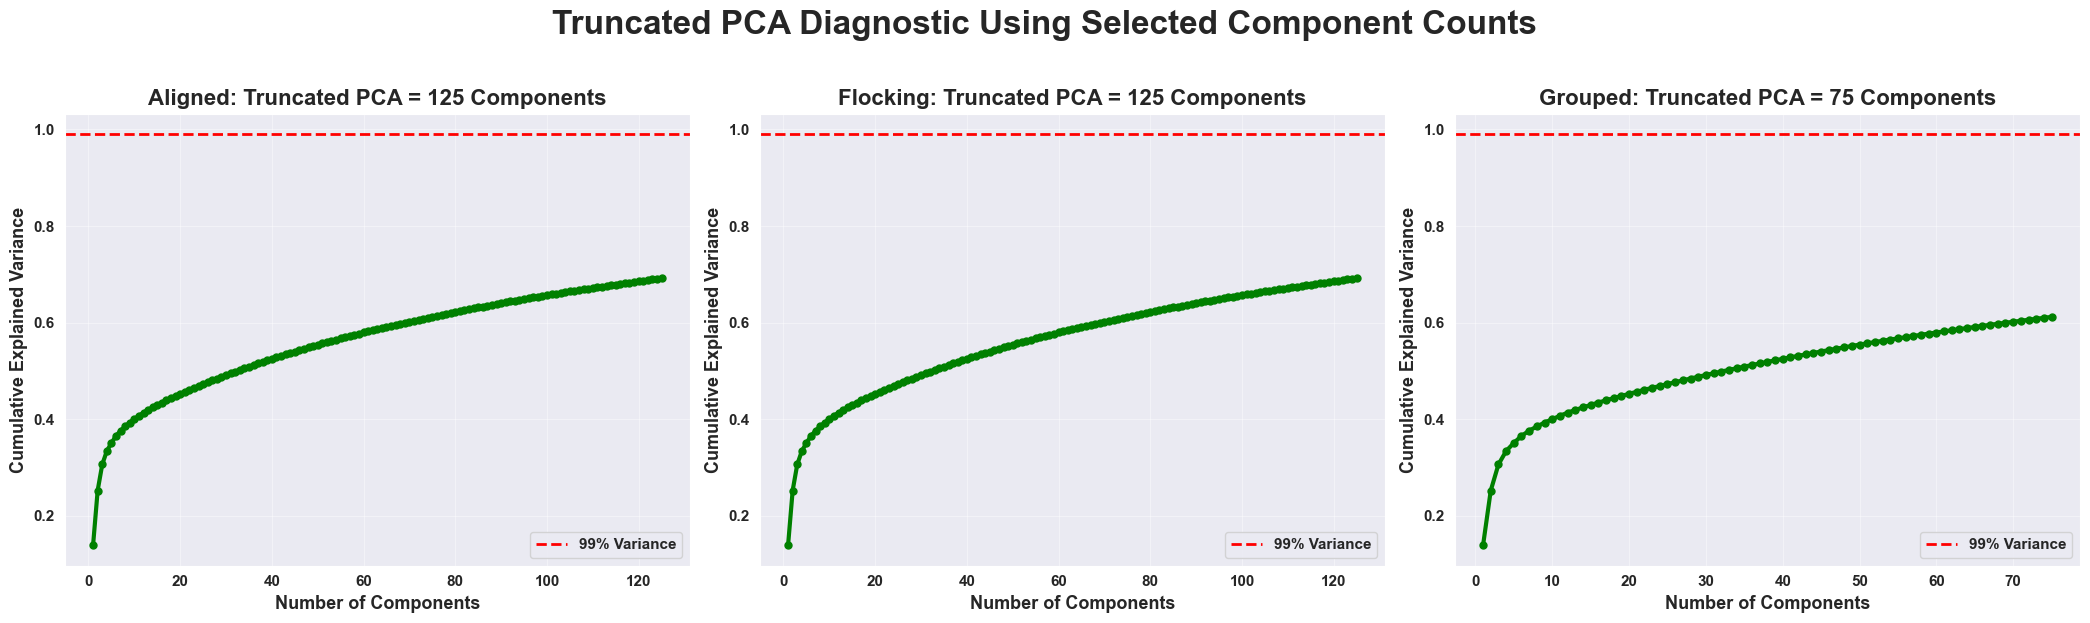

,Dataset,Selected PCA Components,Cumulative Explained Variance,Unexplained Variance
0,Aligned,125,0.691785,0.308215
1,Flocking,125,0.691786,0.308214
2,Grouped,75,0.611820,0.388180


In [115]:
# PCA using the selected component count for each dataset

truncated_pca_results = []

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (dataset_name, df) in zip(axes, datasets.items()):

    # Getting the selected PCA component count for the current dataset
    selected_components = int(
        best_pca_components_df[
            best_pca_components_df["Dataset"] == dataset_name
        ]["PCA Components"].iloc[0]
    )

    # Separating features from the target column
    X = df.drop(columns=["Class"])

    # Standardizing features before PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fitting PCA using the selected component count
    pca_selected = PCA(
        n_components=selected_components,
        svd_solver="randomized",
        random_state=42
    )

    pca_selected.fit(X_scaled)

    # Calculating cumulative explained variance for the selected components
    cumulative_variance = np.cumsum(pca_selected.explained_variance_ratio_)

    # Storing final cumulative variance for this dataset
    truncated_pca_results.append({
        "Dataset": dataset_name,
        "Selected PCA Components": selected_components,
        "Cumulative Explained Variance": cumulative_variance[-1],
        "Unexplained Variance": 1 - cumulative_variance[-1]
    })

    # Plotting cumulative variance across the selected components
    ax.plot(
        range(1, selected_components + 1),
        cumulative_variance,
        marker="o",
        markersize=5,
        linewidth=3,
        color="green"
    )

    # variance reference line
    ax.axhline(
        0.99,
        color="red",
        linestyle="--",
        linewidth=2,
        label="99% Variance"
    )

    # title
    ax.set_title(
        f"{dataset_name}: Truncated PCA = {selected_components} Components",
        fontweight="bold",
        fontsize=16
    )
    
    # x label
    ax.set_xlabel(
        "Number of Components",
        fontweight="bold",
        fontsize=13
    )
    
    # y label
    ax.set_ylabel(
        "Cumulative Explained Variance",
        fontweight="bold",
        fontsize=13
    )

    # tick labels
    ax.tick_params(axis="both", labelsize=11)

    for tick_label in ax.get_xticklabels():
        tick_label.set_fontweight("bold")

    for tick_label in ax.get_yticklabels():
        tick_label.set_fontweight("bold")

    # grid
    ax.grid(True, alpha=0.4)
    # legend
    legend = ax.legend(fontsize=11)
    for text in legend.get_texts():
        text.set_fontweight("bold")

# main title
fig.suptitle(
    "Truncated PCA Diagnostic Using Selected Component Counts",
    fontsize=24,
    fontweight="bold",
    y=1.03
)

# spacing and display
plt.tight_layout()
plt.show()

# Converting truncated PCA results to a DataFrame
truncated_pca_selected_df = pd.DataFrame(truncated_pca_results)

# Displaying the final cumulative variance retained by the selected components
display(truncated_pca_selected_df)

Merging PCA Results
 - Stronger indication of highly separable data at this point.

In [116]:
# Merging PCA variance results with cross-validated F1 results
pca_variance_f1_df = pca_component_df.merge(
    pca_variance_df[[
        "Dataset",
        "PCA Components",
        "Cumulative Explained Variance"
    ]],
    on=["Dataset", "PCA Components"],
    how="left"
)

# Displaying combined PCA diagnostic results
display(pca_variance_f1_df)

,Dataset,PCA Components,Mean CV F1,Std CV F1,Cumulative Explained Variance
0,Aligned,25,0.999867,0.000094,0.472707
1,Aligned,50,0.999800,0.000163,0.554373
2,Aligned,75,0.999867,0.000094,0.612244
3,Aligned,100,0.999933,0.000094,0.656950
4,Aligned,125,1.000000,0.000000,0.692486
5,Aligned,150,0.999933,0.000094,0.722358
6,Aligned,175,0.999867,0.000188,0.748143
7,Aligned,200,0.999933,0.000094,0.770847
8,Flocking,25,0.999417,0.000212,0.472705
9,Flocking,50,0.999542,0.000212,0.554372


Variance retention vs. Classification performance

- Even when cumulative variance is moderate, the Mean CV F1 score is already near 1.0 at very low component counts

Conclusion: The datasets do not need most of the total feature variance to classify well.

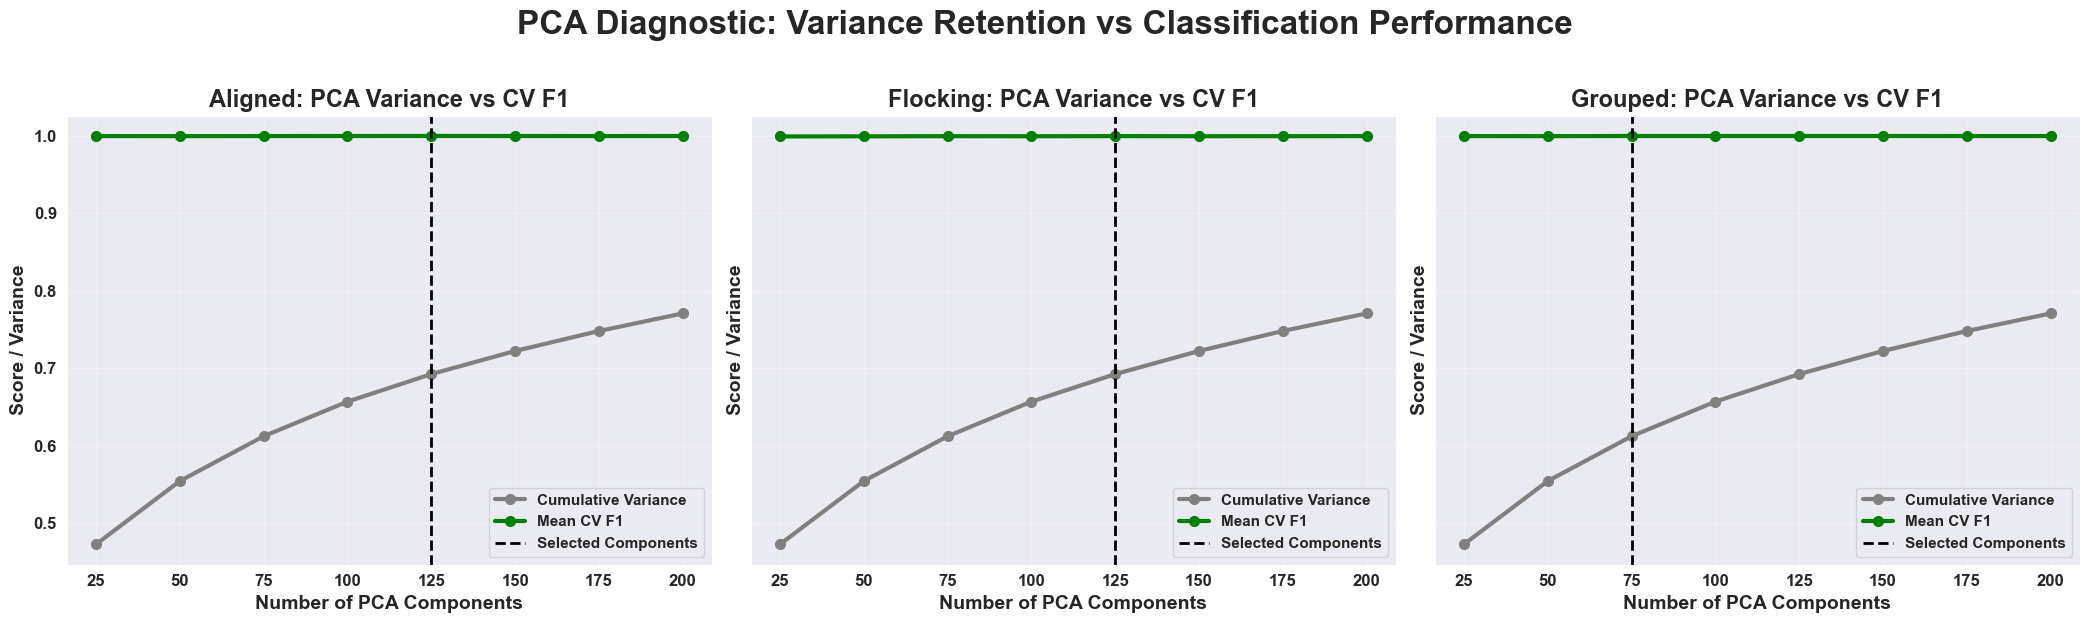

In [117]:
# Plotting cumulative explained variance and CV F1 by PCA component count
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

for ax, dataset_name in zip(axes, pca_variance_f1_df["Dataset"].unique()):

    # Filtering results for the current dataset
    dataset_results = pca_variance_f1_df[
        pca_variance_f1_df["Dataset"] == dataset_name
    ]

    # Getting selected component count for the current dataset
    selected_components = int(
        best_pca_components_df[
            best_pca_components_df["Dataset"] == dataset_name
        ]["PCA Components"].iloc[0]
    )

    # Plotting cumulative explained variance
    ax.plot(
        dataset_results["PCA Components"],
        dataset_results["Cumulative Explained Variance"],
        marker="o",
        linewidth=3,
        markersize=7,
        color="gray",
        label="Cumulative Variance"
    )

    # Plotting mean CV F1 score
    ax.plot(
        dataset_results["PCA Components"],
        dataset_results["Mean CV F1"],
        marker="o",
        linewidth=3,
        markersize=7,
        color="green",
        label="Mean CV F1"
    )

    # Marking selected component count
    ax.axvline(
        selected_components,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Selected Components"
    )

    # Adding chart title and labels
    ax.set_title(
        f"{dataset_name}: PCA Variance vs CV F1",
        fontsize=17,
        fontweight="bold"
    )
    
    # x-axis label
    ax.set_xlabel(
        "Number of PCA Components",
        fontsize=14,
        fontweight="bold"
    )

    # y-axis label
    ax.set_ylabel(
        "Score / Variance",
        fontsize=14,
        fontweight="bold"
    )

    # tick labels
    ax.tick_params(axis="both", labelsize=12)

    for tick_label in ax.get_xticklabels():
        tick_label.set_fontweight("bold")

    for tick_label in ax.get_yticklabels():
        tick_label.set_fontweight("bold")

    # grid
    ax.grid(True, alpha=0.3)
    # legend
    legend = ax.legend(fontsize=11)
    for text in legend.get_texts():
        text.set_fontweight("bold")

# main title
fig.suptitle(
    "PCA Diagnostic: Variance Retention vs Classification Performance",
    fontsize=24,
    fontweight="bold",
    y=1.03
)

# spacing and display plot
plt.tight_layout()
plt.show()

PCA variance tail analysis
 - Most PCA components contribute very little variance individually. 
 - Using a near-zero threshold of 0.001, 2,232 out of 2,400 components, or about 93%, explain less than 0.1% variance each. 
 - This suggests that the strongest variance structure is concentrated in a much smaller subset of components.

In [118]:
# PCA variance tail for each dataset

near_zero_threshold = 0.001
pca_tail_results = []
pca_explained_variance_store = {}

for dataset_name, df in datasets.items():

    # Separating features from the target column
    X = df.drop(columns=["Class"])

    # Standardizing features before PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fitting full PCA using all feature components
    pca = PCA(n_components=X_scaled.shape[1], svd_solver="full")
    pca.fit(X_scaled)

    # Storing explained variance ratios for later diagnostics
    explained_variance = pca.explained_variance_ratio_
    pca_explained_variance_store[dataset_name] = explained_variance

    # Counting components with very small individual explained variance
    near_zero_count = np.sum(explained_variance < near_zero_threshold)

    # Calculating the fraction of components below the threshold
    near_zero_fraction = near_zero_count / len(explained_variance)

    # Calculating how much total variance is in the low-variance tail
    tail_variance = explained_variance[explained_variance < near_zero_threshold].sum()

    # Storing results
    pca_tail_results.append({
        "Dataset": dataset_name,
        "Total Components": len(explained_variance),
        "Near-Zero Threshold": near_zero_threshold,
        "Near-Zero Component Count": near_zero_count,
        "Near-Zero Component Percent": near_zero_fraction * 100,
        "Total Variance in Near-Zero Tail": tail_variance
    })

# Converting results to a DataFrame
pca_tail_df = pd.DataFrame(pca_tail_results)

# Displaying PCA tail summary
display(pca_tail_df)

,Dataset,Total Components,Near-Zero Threshold,Near-Zero Component Count,Near-Zero Component Percent,Total Variance in Near-Zero Tail
0,Aligned,2400,0.001,2232,93.0,0.258727
1,Flocking,2400,0.001,2232,93.0,0.258726
2,Grouped,2400,0.001,2232,93.0,0.258727


Plotting near-zero PCA components for each dataset for visual comparison

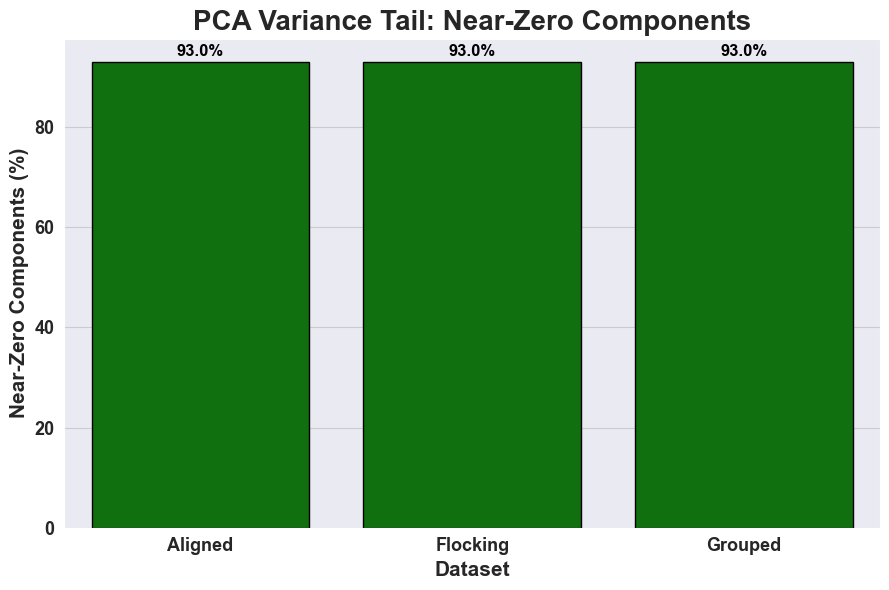

In [119]:
# Plotting the percentage of near-zero PCA components for each dataset
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=pca_tail_df,
    x="Dataset",
    y="Near-Zero Component Percent",
    color="green",
    edgecolor="black"
)

# title label
plt.title(
    "PCA Variance Tail: Near-Zero Components",
    fontsize=20,
    fontweight="bold"
)

# x axis label
plt.xlabel(
    "Dataset",
    fontsize=15,
    fontweight="bold"
)

# y axis label
plt.ylabel(
    "Near-Zero Components (%)",
    fontsize=15,
    fontweight="bold"
)

# tick labels
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

# grid lines
plt.grid(axis="y", color="gray", alpha=0.3)

# value labels above bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="black"
    )
# spacing and display
plt.tight_layout()
plt.show()

Checking effective rank of data
- The effective rank is a estimate of how many PCA components meaningfully contribute to total variance.
- Considering that the datasets are high-dimensional in their original form, but PCA diagnostics suggest lower-dimensional structure, the data behaves as if its meaningful variance is is concentrated in a smaller subspace.


In [120]:
# Computing entropy-based effective rank from PCA explained variance ratios
# Effective rank estimates how many PCA directions meaningfully contribute to total variance.

effective_rank_results = []

for dataset_name, explained_variance in pca_explained_variance_store.items():

    # Normalizing explained variance ratios
    p = explained_variance / explained_variance.sum()

    # Removing zero values before applying the logarithm
    p = p[p > 0]

    # Computing entropy-based effective rank
    effective_rank = np.exp(-np.sum(p * np.log(p)))

    # Computing effective rank as a percentage of all PCA components
    effective_rank_percent = (effective_rank / len(explained_variance)) * 100

    # Storing results
    effective_rank_results.append({
        "Dataset": dataset_name,
        "Total Components": len(explained_variance),
        "Effective Rank": effective_rank,
        "Effective Rank Percent": effective_rank_percent
    })

# Converting results to a DataFrame
effective_rank_df = pd.DataFrame(effective_rank_results)

# Displaying effective rank results
display(effective_rank_df)

,Dataset,Total Components,Effective Rank,Effective Rank Percent
0,Aligned,2400,188.687698,7.861987
1,Flocking,2400,188.687370,7.861974
2,Grouped,2400,188.687698,7.861987


Plotting effective rank results for each dataset for visual comparison

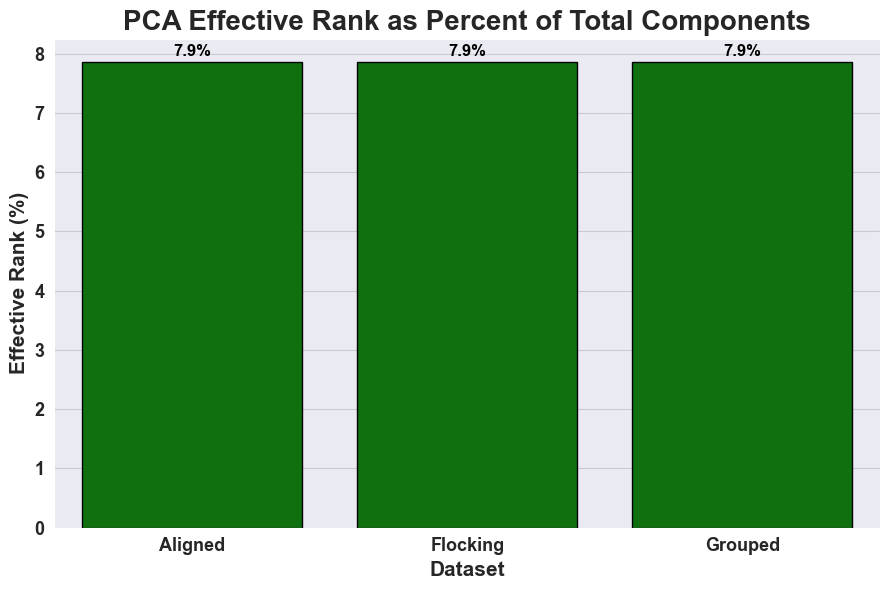

In [121]:
# Plotting effective rank percentage for each dataset
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=effective_rank_df,
    x="Dataset",
    y="Effective Rank Percent",
    color="green",
    edgecolor="black"
)

# title
plt.title(
    "PCA Effective Rank as Percent of Total Components",
    fontsize=20,
    fontweight="bold"
)

# labels
plt.xlabel("Dataset", fontsize=15, fontweight="bold")
plt.ylabel("Effective Rank (%)", fontsize=15, fontweight="bold")

# tick labels
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

# grid lines
plt.grid(axis="y", color="gray", alpha=0.3)

# values above bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="black"
    )
# spacing and display
plt.tight_layout()
plt.show()

# EDA Conclusion
The Aligned, Flocking, and Grouped Swarm Behaviour datasets are high-dimensional binary classification datasets with nearly identical feature structures. After cleaning, Aligned and Grouped each contain 24,016 rows and 2,401 total columns, while Flocking contains 24,015 rows and 2,401 total columns after removing one malformed row. All datasets include 2,400 numerical features and one binary `Class` label, and feature ordering is consistent across datasets. The primary difference between datasets is class balance. Flocking is almost perfectly balanced, while Grouped and especially Aligned show moderate to strong imbalance. Because of this, F1-score is a more reliable evaluation metric than accuracy alone. Distribution and outlier analysis shows that many features contain extreme or sparse values. The IQR method flagged outliers in roughly 1,674–1,676 features per dataset, but these appear to reflect sparsity rather than data errors. PCA reveals that the datasets are high-dimensional but highly compressible. The first three components explain about 30.63% of variance, 25 components explain about 47.27%, 100 explain about 65.70%, and 200 explain about 77.08%, indicating redundancy in the 2,400-dimensional feature space. Despite this, PCA-based classification shows that only a small number of components are needed. This demonstrates that the class-separating structure is extremely compact. PCA tail and effective rank analysis confirm this. Across all datasets, about 93% individually explain less than 0.001 variance. The entropy-based effective rank is about 7.86% of the feature space, showing that although the datasets are high-dimensional, the meaningful variance behaves like a much smaller latent subspace.

Overall, the EDA shows that the Swarm Behaviour datasets highly separable. All three share nearly identical variance structure and PCA behavior, and the classification signal is extremely compact. The difficulty of the problem arises not from overlapping classes but from the large number of redundant features, sparse behavioral patterns, and differing class balances.

# Feature/Target Separation

After completing EDA on the full cleaned datasets, the features and target labels were separated for each dataset.

In [122]:
# Separating features and target for each dataset
X_aligned = aligned_df.drop("Class", axis=1)
y_aligned = aligned_df["Class"]

X_flocking = flocking_df.drop("Class", axis=1)
y_flocking = flocking_df["Class"]

X_grouped = grouped_df.drop("Class", axis=1)
y_grouped = grouped_df["Class"]

# Displaying shapes
print("Aligned X shape:", X_aligned.shape)
print("Aligned y shape:", y_aligned.shape)
print()

print("Flocking X shape:", X_flocking.shape)
print("Flocking y shape:", y_flocking.shape)
print()

print("Grouped X shape:", X_grouped.shape)
print("Grouped y shape:", y_grouped.shape)

Aligned X shape: (24016, 2400)
Aligned y shape: (24016,)

Flocking X shape: (24015, 2400)
Flocking y shape: (24015,)

Grouped X shape: (24016, 2400)
Grouped y shape: (24016,)


# Spliting into training and testing sets

- Using an 80% - 20% split.
- Stratified sampling was applied so that the class proportions remain consistent for model preparation in both the training and testing data.

In [123]:
# Splitting each dataset into training and testing sets
# The data was split into 80% training and 20% testing sets
# Stratified sampling was used to preserve the original class distribution
X_train_aligned, X_test_aligned, y_train_aligned, y_test_aligned = train_test_split(
    X_aligned, y_aligned, test_size=0.2, random_state=42, stratify=y_aligned
)

X_train_flocking, X_test_flocking, y_train_flocking, y_test_flocking = train_test_split(
    X_flocking, y_flocking, test_size=0.2, random_state=42, stratify=y_flocking
)

X_train_grouped, X_test_grouped, y_train_grouped, y_test_grouped = train_test_split(
    X_grouped, y_grouped, test_size=0.2, random_state=42, stratify=y_grouped
)

# Displaying the shapes of the 3 split datasets
print("Aligned:")
print("X_train:", X_train_aligned.shape)
print("X_test:", X_test_aligned.shape)
print("y_train:", y_train_aligned.shape)
print("y_test:", y_test_aligned.shape)
print()

print("Flocking:")
print("X_train:", X_train_flocking.shape)
print("X_test:", X_test_flocking.shape)
print("y_train:", y_train_flocking.shape)
print("y_test:", y_test_flocking.shape)
print()

print("Grouped:")
print("X_train:", X_train_grouped.shape)
print("X_test:", X_test_grouped.shape)
print("y_train:", y_train_grouped.shape)
print("y_test:", y_test_grouped.shape)

Aligned:
X_train: (19212, 2400)
X_test: (4804, 2400)
y_train: (19212,)
y_test: (4804,)

Flocking:
X_train: (19212, 2400)
X_test: (4803, 2400)
y_train: (19212,)
y_test: (4803,)

Grouped:
X_train: (19212, 2400)
X_test: (4804, 2400)
y_train: (19212,)
y_test: (4804,)


# Model Selection Logic

Based on the EDA, the Swarm Behaviour datasets appear to have a compact and highly separable class structure. PCA showed that much of the meaningful variance is concentrated in a smaller lower-dimensional subspace, and the exploratory PCA-based Linear SVC diagnostic produced near-perfect cross-validation F1-scores using only 25 principal components. Because of this, linear models are strong candidates for this problem.The selected linear models are Logistic Regression, Ridge Classifier, and Linear SVC. Logistic Regression and Ridge Classifier were chosen because they use regularization, which is helpful for high-dimensional and redundant feature spaces. Linear SVC was chosen because it performs well on high-dimensional linear classification problems and already showed strong exploratory performance during EDA.Random Forest and XGBoost were included because they are required for the project and provide nonlinear ensemble comparisons. A Decision Tree was also included as a simpler comparison model because it is interpretable but may overfit high-dimensional data.

- The final model set includes Logistic Regression, Ridge Classifier, Linear SVC, Decision Tree, Random Forest, and XGBoost. Because Aligned and Grouped contain class imbalance, F1-score will be used as the primary evaluation metric, with accuracy, precision, recall, and ROC-AUC also reported for comparison.

# Untuned Baseline Models (For Later Comparison)
 - All baseline metrics (accuracy, precision, recall, F1, ROC AUC) were computed using cross validation on the training set. 
 - Each model was trained on the fold’s training portion and evaluated on that fold’s validation portion, ensuring that all baseline scores reflect performance on unseen data.
 - Baseline metrics come from predictions made on validation folds, not on the training data the model was fit on.
 - Untuned results will help determine how much tuning is need for the models if much at all.

This cell prepares the training datasets, cross-validation strategy, and untuned baseline models for the first modeling comparison. Only the training sets are stored in `training_datasets`, which keeps the held-out test sets untouched until final model evaluation.

A 3-fold stratified cross-validation strategy is used so each fold preserves the original class distribution. This is important because the Aligned and Grouped datasets contain class imbalance.

The untuned baseline models include Logistic Regression, Ridge Classifier, Linear SVC, Decision Tree, Random Forest, and XGBoost. Scaling is included inside pipelines for the linear models because they are sensitive to feature scale. Keeping `StandardScaler` inside the pipeline prevents data leakage because scaling is fit only on the training portion of each cross-validation fold.

In [124]:
# Creating a dictionary of training datasets only
training_datasets = {
    "Aligned": (X_train_aligned, y_train_aligned),
    "Flocking": (X_train_flocking, y_train_flocking),
    "Grouped": (X_train_grouped, y_train_grouped)
}

# Defining stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Defining untuned baseline models
untuned_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier())
    ]),

    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(max_iter=5000, random_state=42, dual=False))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1
    )
}

This cell defines a helper function for calculating ROC-AUC across different model types. Some classifiers, such as Logistic Regression, Random Forest, and XGBoost, produce probability scores with `predict_proba()`. Other classifiers, such as Linear SVC and Ridge Classifier, produce decision scores with `decision_function()` instead.

The function checks which scoring method the model supports and returns the correct score values for ROC-AUC calculation. This allows ROC-AUC to be evaluated consistently across all baseline models.

In [125]:
# Function to get ROC-AUC scores from different model types
# Some models use predict_proba, while LinearSVC and RidgeClassifier use decision_function
def get_auc_scores(model, X_valid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_valid)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X_valid)
    else:
        return None

This cell runs the untuned baseline model comparison using only the training data. Each model is evaluated with stratified cross-validation so the class proportions remain consistent across folds. The held-out test sets are not used in this step, which prevents test-set leakage and keeps final evaluation fair.

For each dataset and model, the code trains on each cross-validation training fold and evaluates it on the matching validation fold. The cell records accuracy, precision, recall, F1-score, ROC-AUC, average fit time, and average prediction time. Prediction time represents inference speed, or how long the trained model takes to generate predictions.

The results are stored in a DataFrame and sorted by dataset, F1-score, and ROC-AUC. These untuned baseline results provide the comparison point for later tuned models.

In [126]:
# Running untuned baseline comparison using training data only
baseline_results = []

for dataset_name, (X_train, y_train) in training_datasets.items():

    print(f"Running baseline models for {dataset_name}...")

    for model_name, model in untuned_models.items():

        print(f"  Model: {model_name}")

        fold_accuracies = []
        fold_precisions = []
        fold_recalls = []
        fold_f1_scores = []
        fold_roc_aucs = []
        fold_fit_times = []
        fold_predict_times = []

        for train_index, valid_index in cv_strategy.split(X_train, y_train):

            # Creating cross-validation training and validation folds
            X_cv_train = X_train.iloc[train_index]
            X_cv_valid = X_train.iloc[valid_index]
            y_cv_train = y_train.iloc[train_index]
            y_cv_valid = y_train.iloc[valid_index]

            # Cloning the model so each fold starts fresh
            model_clone = clone(model)

            # Measuring fit time
            fit_start_time = time.time()
            model_clone.fit(X_cv_train, y_cv_train)
            fit_end_time = time.time()

            # Measuring prediction/inference time
            predict_start_time = time.time()
            y_pred = model_clone.predict(X_cv_valid)
            predict_end_time = time.time()

            # Getting scores for ROC-AUC
            y_auc_scores = get_auc_scores(model_clone, X_cv_valid)

            # Calculating metrics
            fold_accuracies.append(accuracy_score(y_cv_valid, y_pred))
            fold_precisions.append(precision_score(y_cv_valid, y_pred, zero_division=0))
            fold_recalls.append(recall_score(y_cv_valid, y_pred, zero_division=0))
            fold_f1_scores.append(f1_score(y_cv_valid, y_pred, zero_division=0))

            if y_auc_scores is not None:
                fold_roc_aucs.append(roc_auc_score(y_cv_valid, y_auc_scores))
            else:
                fold_roc_aucs.append(np.nan)

            fold_fit_times.append(fit_end_time - fit_start_time)
            fold_predict_times.append(predict_end_time - predict_start_time)

        # Storing average results across folds
        baseline_results.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Baseline Accuracy": np.mean(fold_accuracies),
            "Baseline Precision": np.mean(fold_precisions),
            "Baseline Recall": np.mean(fold_recalls),
            "Baseline F1": np.mean(fold_f1_scores),
            "Baseline ROC-AUC": np.mean(fold_roc_aucs),
            "Average Fit Time (sec)": np.mean(fold_fit_times),
            "Average Predict Time (sec)": np.mean(fold_predict_times)
        })

# Converting results to a DataFrame
baseline_results_df = pd.DataFrame(baseline_results)

# Sorting by dataset and primary metric
baseline_results_df = baseline_results_df.sort_values(
    by=["Dataset", "Baseline F1", "Baseline ROC-AUC"],
    ascending=[True, False, False]
).reset_index(drop=True)

# Displaying baseline results
display(baseline_results_df)

Running baseline models for Aligned...
  Model: Logistic Regression
  Model: Ridge Classifier
  Model: Linear SVC
  Model: Decision Tree
  Model: Random Forest
  Model: XGBoost
Running baseline models for Flocking...
  Model: Logistic Regression
  Model: Ridge Classifier
  Model: Linear SVC
  Model: Decision Tree
  Model: Random Forest
  Model: XGBoost
Running baseline models for Grouped...
  Model: Logistic Regression
  Model: Ridge Classifier
  Model: Linear SVC
  Model: Decision Tree
  Model: Random Forest
  Model: XGBoost


,Dataset,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Baseline ROC-AUC,Average Fit Time (sec),Average Predict Time (sec)
0,Aligned,Linear SVC,1.000000,1.000000,1.000000,1.000000,1.000000,2.911280,0.155235
1,Aligned,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.698154,0.118479
2,Aligned,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,9.821089,0.776257
3,Aligned,Logistic Regression,0.999896,0.999667,1.000000,0.999833,1.000000,2.068210,0.174901
4,Aligned,Ridge Classifier,0.999896,0.999667,1.000000,0.999833,1.000000,1.548891,0.152339
5,Aligned,Decision Tree,0.998803,0.997505,0.998668,0.998086,0.998766,8.522740,0.079550
6,Flocking,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,3.820903,0.185418
7,Flocking,Logistic Regression,0.999948,0.999896,1.000000,0.999948,1.000000,1.450279,0.156478
8,Flocking,Linear SVC,0.999948,1.000000,0.999896,0.999948,1.000000,3.539036,0.159559
9,Flocking,XGBoost,0.999948,1.000000,0.999896,0.999948,1.000000,10.207946,0.260087


# After running the untuned baseline comparison, the results show that all models achieved near-perfect performance on the training data. 
- This supports the EDA finding that the data is highly separable. 
- The untuned baseline results suggest that extensive hyperparameter tuning may not be necessary to achieve excellent performance on these datasets. 
- Due to near perfect F1, Recall, and ROC AUC performance of the baseline models the final model will be selected based F1, predictive performance, and then ROC AUC.


# Next I will do some light tuning for comparison against the baseline models, and review PCA benefits for the linear models.
 - The goal of this section is not to search a large hyperparameter space, but to determine whether small tuning adjustments improve performance and whether PCA-based dimensionality reduction can preserve accuracy while reducing computational cost.
- All tuning is performed using cross-validation on the training data only. The held-out test sets remain untouched until final model evaluation. This prevents data leakage and ensures that the final test results represent true unseen-data performance.
- This should help confirm whether the strong baseline performance can be improved with tuning, and whether PCA can provide a better speed-accuracy tradeoff for the linear models. 

This cell defines a helper function for measuring prediction time after tuning. The function takes the best model found by GridSearchCV, refits it inside each cross-validation fold, and records the average time needed to generate predictions on the validation fold. This keeps the timing comparison consistent with the baseline model comparison.

In [127]:
# Function to evaluate the best tuned model with cross-validation timing
def evaluate_best_model_cv(best_model, X_train, y_train, cv_strategy):

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1_scores = []
    fold_roc_aucs = []
    fold_fit_times = []
    fold_predict_times = []

    for train_index, valid_index in cv_strategy.split(X_train, y_train):

        # Creating cross-validation training and validation folds
        X_cv_train = X_train.iloc[train_index]
        X_cv_valid = X_train.iloc[valid_index]
        y_cv_train = y_train.iloc[train_index]
        y_cv_valid = y_train.iloc[valid_index]

        # Cloning the tuned model so each fold starts fresh
        model_clone = clone(best_model)

        # Measuring fit time
        fit_start_time = time.time()
        model_clone.fit(X_cv_train, y_cv_train)
        fit_end_time = time.time()

        # Measuring prediction/inference time
        predict_start_time = time.time()
        y_pred = model_clone.predict(X_cv_valid)
        predict_end_time = time.time()

        # Getting scores for ROC-AUC
        y_auc_scores = get_auc_scores(model_clone, X_cv_valid)

        # Calculating metrics
        fold_accuracies.append(accuracy_score(y_cv_valid, y_pred))
        fold_precisions.append(precision_score(y_cv_valid, y_pred, zero_division=0))
        fold_recalls.append(recall_score(y_cv_valid, y_pred, zero_division=0))
        fold_f1_scores.append(f1_score(y_cv_valid, y_pred, zero_division=0))

        if y_auc_scores is not None:
            fold_roc_aucs.append(roc_auc_score(y_cv_valid, y_auc_scores))
        else:
            fold_roc_aucs.append(np.nan)

        fold_fit_times.append(fit_end_time - fit_start_time)
        fold_predict_times.append(predict_end_time - predict_start_time)

    return {
        "Tuned Accuracy": np.mean(fold_accuracies),
        "Tuned Precision": np.mean(fold_precisions),
        "Tuned Recall": np.mean(fold_recalls),
        "Tuned F1": np.mean(fold_f1_scores),
        "Tuned ROC-AUC": np.mean(fold_roc_aucs),
        "Average Fit Time (sec)": np.mean(fold_fit_times),
        "Average Predict Time (sec)": np.mean(fold_predict_times)
    }

# Defining lightly tuned model pipelines and parameter grids
- For linear models StandardScaler is applied before modeling.
- PCA variants from 10 to 50 components are included to test whether low-dimensional feature spaces improve prediction time while preserving performance.
- SelectKBest(200) is included to test whether selecting approximately 8% of the original 2,400 features preserves performance while improving runtime.

In [128]:
# configuring lightly tuned models with PCA and SelectKBest variants for comparison against baselines.
tuned_model_configs = {

    # Logistic Regression: no PCA, PCA(10), PCA(20), PCA(30), PCA(40), PCA(50), SelectKBest(200)
    "Logistic Regression No PCA": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Logistic Regression PCA(10)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=10, svd_solver="randomized", random_state=42)),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 10,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Logistic Regression PCA(20)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=20, svd_solver="randomized", random_state=42)),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 20,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Logistic Regression PCA(30)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, svd_solver="randomized", random_state=42)),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 30,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Logistic Regression PCA(40)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=40, svd_solver="randomized", random_state=42)),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 40,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Logistic Regression PCA(50)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, svd_solver="randomized", random_state=42)),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 50,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Logistic Regression SelectKBest(200)": {
        "model": Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=200)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": True,
        "selected_features": 200
    },

    # Ridge Classifier: no PCA, PCA(10), PCA(20), PCA(30), PCA(40), PCA(50), SelectKBest(200)
    "Ridge Classifier No PCA": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Ridge Classifier PCA(10)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=10, svd_solver="randomized", random_state=42)),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 10,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Ridge Classifier PCA(20)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=20, svd_solver="randomized", random_state=42)),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 20,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Ridge Classifier PCA(30)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, svd_solver="randomized", random_state=42)),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 30,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Ridge Classifier PCA(40)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=40, svd_solver="randomized", random_state=42)),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 40,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Ridge Classifier PCA(50)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, svd_solver="randomized", random_state=42)),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 50,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Ridge Classifier SelectKBest(200)": {
        "model": Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=200)),
            ("scaler", StandardScaler()),
            ("model", RidgeClassifier())
        ]),
        "params": {
            "model__alpha": [0.1, 1, 10]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": True,
        "selected_features": 200
    },

    # Linear SVC: no PCA, PCA(10), PCA(20), PCA(30), PCA(40), PCA(50), SelectKBest(200)
    "Linear SVC No PCA": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Linear SVC PCA(10)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=10, svd_solver="randomized", random_state=42)),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 10,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Linear SVC PCA(20)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=20, svd_solver="randomized", random_state=42)),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 20,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Linear SVC PCA(30)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, svd_solver="randomized", random_state=42)),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 30,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Linear SVC PCA(40)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=40, svd_solver="randomized", random_state=42)),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 40,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Linear SVC PCA(50)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, svd_solver="randomized", random_state=42)),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": True,
        "pca_components": 50,
        "feature_selection_used": False,
        "selected_features": 0
    },

    "Linear SVC SelectKBest(200)": {
        "model": Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=200)),
            ("scaler", StandardScaler()),
            ("model", LinearSVC(max_iter=10000, random_state=42, dual=False))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": True,
        "selected_features": 200
    },

    # Decision Tree: no PCA/full feature space only
    "Decision Tree No PCA": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": False,
        "selected_features": 0
    },

    # Required ensemble model: Random Forest
    "Random Forest No PCA": {
        "model": RandomForestClassifier(random_state=42, n_jobs=1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 20]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": False,
        "selected_features": 0
    },

    # Required ensemble model: XGBoost
    "XGBoost No PCA": {
        "model": XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=1
        ),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5]
        },
        "pca_used": False,
        "pca_components": 0,
        "feature_selection_used": False,
        "selected_features": 0
    }
}

# Minimal hyperparameter tuning
This cell runs GridSearchCV for each tuned model configuration. The search uses F1-score as the primary scoring metric because the Aligned and Grouped datasets are imbalanced. Each model is tuned using only the training data and stratified cross-validation.

After GridSearchCV identifies the best parameter setting, the best model is evaluated again across the same cross-validation structure to record accuracy, precision, recall, F1-score, ROC-AUC, fit time, and prediction/inference time. The held-out test set is still not used.

In [129]:
# Running light hyperparameter tuning on training data only
# GridSearchCV uses limited parallel jobs to reduce memory pressure.
# This loop supports No Pca, PCA, and SelectKBest model configurations.

tuned_results = []

for dataset_name, (X_train, y_train) in training_datasets.items():

    print(f"Running light tuning for {dataset_name}...")

    for config_name, config in tuned_model_configs.items():

        print(f"  Tuning: {config_name}")

        # Creating GridSearchCV object
        # n_jobs=2 avoids excessive memory use from parallel CV workers.
        # pre_dispatch limits how many jobs are created ahead of time.
        grid_search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring="f1",
            cv=cv_strategy,
            n_jobs=2,
            pre_dispatch="2*n_jobs",
            refit=True
        )

        # Measuring total GridSearchCV time
        search_start_time = time.time()
        grid_search.fit(X_train, y_train)
        search_end_time = time.time()

        # Getting the best tuned model
        best_model = grid_search.best_estimator_

        # Evaluating the best tuned model with CV timing
        tuned_cv_metrics = evaluate_best_model_cv(
            best_model=best_model,
            X_train=X_train,
            y_train=y_train,
            cv_strategy=cv_strategy
        )

        # Storing results
        tuned_results.append({
            "Dataset": dataset_name,
            "Model": config_name,
            "PCA Used": config["pca_used"],
            "PCA Components": config["pca_components"],
            "Feature Selection Used": config.get("feature_selection_used", False),
            "Selected Features": config.get("selected_features", 0),
            "Best Parameters": grid_search.best_params_,
            "Best CV F1 From GridSearch": grid_search.best_score_,
            "GridSearch Time (sec)": search_end_time - search_start_time,
            "Tuned Accuracy": tuned_cv_metrics["Tuned Accuracy"],
            "Tuned Precision": tuned_cv_metrics["Tuned Precision"],
            "Tuned Recall": tuned_cv_metrics["Tuned Recall"],
            "Tuned F1": tuned_cv_metrics["Tuned F1"],
            "Tuned ROC-AUC": tuned_cv_metrics["Tuned ROC-AUC"],
            "Average Fit Time (sec)": tuned_cv_metrics["Average Fit Time (sec)"],
            "Average Predict Time (sec)": tuned_cv_metrics["Average Predict Time (sec)"]
        })

# Creating tuned results DataFrame
tuned_results_df = pd.DataFrame(tuned_results)

# Sorting by dataset, tuned F1, ROC-AUC, and prediction time
tuned_results_df = tuned_results_df.sort_values(
    by=["Dataset", "Tuned F1", "Tuned ROC-AUC", "Average Predict Time (sec)"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

# Displaying tuned results
display(tuned_results_df)

Running light tuning for Aligned...
  Tuning: Logistic Regression No PCA
  Tuning: Logistic Regression PCA(10)
  Tuning: Logistic Regression PCA(20)
  Tuning: Logistic Regression PCA(30)
  Tuning: Logistic Regression PCA(40)
  Tuning: Logistic Regression PCA(50)
  Tuning: Logistic Regression SelectKBest(200)
  Tuning: Ridge Classifier No PCA
  Tuning: Ridge Classifier PCA(10)
  Tuning: Ridge Classifier PCA(20)
  Tuning: Ridge Classifier PCA(30)
  Tuning: Ridge Classifier PCA(40)
  Tuning: Ridge Classifier PCA(50)
  Tuning: Ridge Classifier SelectKBest(200)
  Tuning: Linear SVC No PCA
  Tuning: Linear SVC PCA(10)
  Tuning: Linear SVC PCA(20)
  Tuning: Linear SVC PCA(30)
  Tuning: Linear SVC PCA(40)
  Tuning: Linear SVC PCA(50)
  Tuning: Linear SVC SelectKBest(200)
  Tuning: Decision Tree No PCA
  Tuning: Random Forest No PCA
  Tuning: XGBoost No PCA
Running light tuning for Flocking...
  Tuning: Logistic Regression No PCA
  Tuning: Logistic Regression PCA(10)
  Tuning: Logistic Regressi

,Dataset,Model,PCA Used,PCA Components,Feature Selection Used,Selected Features,Best Parameters,Best CV F1 From GridSearch,GridSearch Time (sec),Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1,Tuned ROC-AUC,Average Fit Time (sec),Average Predict Time (sec)
0,Aligned,Random Forest No PCA,False,0,False,0,"{'max_depth': None, 'n_estimators': 100}",1.000000,127.951110,1.000000,1.000000,1.000000,1.000000,1.000000,11.024916,0.109299
1,Aligned,Linear SVC No PCA,False,0,False,0,{'model__C': 0.1},1.000000,23.481427,1.000000,1.000000,1.000000,1.000000,1.000000,2.955280,0.150829
2,Aligned,Ridge Classifier No PCA,False,0,False,0,{'model__alpha': 10},1.000000,15.103477,1.000000,1.000000,1.000000,1.000000,1.000000,1.434325,0.158374
3,Aligned,Logistic Regression PCA(20),True,20,False,0,{'model__C': 0.1},1.000000,17.333097,1.000000,1.000000,1.000000,1.000000,1.000000,1.458551,0.163197
4,Aligned,Logistic Regression PCA(30),True,30,False,0,{'model__C': 0.1},1.000000,18.112698,1.000000,1.000000,1.000000,1.000000,1.000000,1.548388,0.164949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Grouped,Ridge Classifier PCA(40),True,40,False,0,{'model__alpha': 0.1},0.990986,16.612673,0.993285,0.997749,0.984316,0.990986,0.999165,1.481477,0.166511
68,Grouped,Ridge Classifier PCA(20),True,20,False,0,{'model__alpha': 0.1},0.990703,15.296593,0.993077,0.997748,0.983761,0.990703,0.999076,1.367550,0.155157
69,Grouped,Ridge Classifier PCA(30),True,30,False,0,{'model__alpha': 0.1},0.990634,15.681304,0.993025,0.997747,0.983622,0.990634,0.999082,1.410924,0.161457
70,Grouped,Ridge Classifier SelectKBest(200),False,0,True,200,{'model__alpha': 10},0.980983,8.529329,0.985790,0.985067,0.976961,0.980983,0.997078,0.881305,0.075355


Quick check for missing model configs in tuned results

In [130]:
missing_configs = []

for model_name in tuned_results_df["Model"].unique():
    if model_name not in tuned_model_configs:
        missing_configs.append(model_name)

print("Missing model configs:")
print(missing_configs)

Missing model configs:
[]


# Untuned vs Minimal Tuned Model Comparison

This section combines the untuned baseline results with the minimal tuned model results. The goal is to determine whether hyperparameter tuning, PCA-based dimensionality reduction, or SlectKBest produced meaningful improvement over the baseline models. 

Additionally, this comparison will help identify which model configurations provide the best speed-accuracy tradeoff for final model selection.

The comparison uses average cross-validation performance across the Aligned, Flocking, and Grouped datasets. F1-score remains the primary metric, while ROC-AUC, fit time, prediction time, model simplicity, and PCA usage are used as tie-breakers.

In [131]:
# Combining baseline and tuned results for comparison

# Preparing baseline results
baseline_compare_df = baseline_results_df.copy()

baseline_compare_df["Model Version"] = "Baseline"
baseline_compare_df["PCA Used"] = False
baseline_compare_df["PCA Components"] = 0
baseline_compare_df["Best Parameters"] = "Baseline / Default"
baseline_compare_df["GridSearch Time (sec)"] = np.nan

# Renaming baseline columns to common comparison names
baseline_compare_df = baseline_compare_df.rename(columns={
    "Model": "Algorithm",
    "Baseline Accuracy": "CV Accuracy",
    "Baseline Precision": "CV Precision",
    "Baseline Recall": "CV Recall",
    "Baseline F1": "CV F1",
    "Baseline ROC-AUC": "CV ROC-AUC"
})

baseline_compare_df = baseline_compare_df[
    [
        "Dataset",
        "Algorithm",
        "Model Version",
        "PCA Used",
        "PCA Components",
        "Best Parameters",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "CV ROC-AUC",
        "Average Fit Time (sec)",
        "Average Predict Time (sec)",
        "GridSearch Time (sec)"
    ]
]


# Preparing tuned results
tuned_compare_df = tuned_results_df.copy()

# Creating a clean algorithm name
# This removes feature-space labels while preserving the algorithm name.
tuned_compare_df["Algorithm"] = (
    tuned_compare_df["Model"]
    .str.replace(r" No PCA$", "", regex=True)
    .str.replace(r" Raw$", "", regex=True)
    .str.replace(r" PCA\(\d+\)$", "", regex=True)
    .str.replace(r" SelectKBest\(\d+\)$", "", regex=True)
)

# Creating a model version label
# This separates tuning status from the feature-space strategy.
tuned_compare_df["Model Version"] = np.where(
    tuned_compare_df["PCA Used"] == True,
    "Tuned PCA(" + tuned_compare_df["PCA Components"].astype(str) + ")",
    np.where(
        tuned_compare_df["Feature Selection Used"] == True,
        "Tuned SelectKBest(" + tuned_compare_df["Selected Features"].astype(str) + ")",
        "Tuned No PCA"
    )
)

# Renaming tuned columns to common comparison names
tuned_compare_df = tuned_compare_df.rename(columns={
    "Tuned Accuracy": "CV Accuracy",
    "Tuned Precision": "CV Precision",
    "Tuned Recall": "CV Recall",
    "Tuned F1": "CV F1",
    "Tuned ROC-AUC": "CV ROC-AUC"
})

tuned_compare_df = tuned_compare_df[
    [
        "Dataset",
        "Algorithm",
        "Model Version",
        "PCA Used",
        "PCA Components",
        "Best Parameters",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "CV ROC-AUC",
        "Average Fit Time (sec)",
        "Average Predict Time (sec)",
        "GridSearch Time (sec)"
    ]
]


# Combining baseline and tuned results
model_comparison_df = pd.concat(
    [baseline_compare_df, tuned_compare_df],
    ignore_index=True
)

# Sorting comparison table
model_comparison_df = model_comparison_df.sort_values(
    by=["Dataset", "CV F1", "CV ROC-AUC", "Average Predict Time (sec)"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

display(model_comparison_df)

,Dataset,Algorithm,Model Version,PCA Used,PCA Components,Best Parameters,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Average Fit Time (sec),Average Predict Time (sec),GridSearch Time (sec)
0,Aligned,Random Forest,Tuned No PCA,False,0,"{'max_depth': None, 'n_estimators': 100}",1.000000,1.000000,1.000000,1.000000,1.000000,11.024916,0.109299,127.951110
1,Aligned,Random Forest,Baseline,False,0,Baseline / Default,1.000000,1.000000,1.000000,1.000000,1.000000,1.698154,0.118479,NaN
2,Aligned,Linear SVC,Tuned No PCA,False,0,{'model__C': 0.1},1.000000,1.000000,1.000000,1.000000,1.000000,2.955280,0.150829,23.481427
3,Aligned,Linear SVC,Baseline,False,0,Baseline / Default,1.000000,1.000000,1.000000,1.000000,1.000000,2.911280,0.155235,NaN
4,Aligned,Ridge Classifier,Tuned No PCA,False,0,{'model__alpha': 10},1.000000,1.000000,1.000000,1.000000,1.000000,1.434325,0.158374,15.103477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Grouped,Ridge Classifier,Tuned PCA(40),True,40,{'model__alpha': 0.1},0.993285,0.997749,0.984316,0.990986,0.999165,1.481477,0.166511,16.612673
86,Grouped,Ridge Classifier,Tuned PCA(20),True,20,{'model__alpha': 0.1},0.993077,0.997748,0.983761,0.990703,0.999076,1.367550,0.155157,15.296593
87,Grouped,Ridge Classifier,Tuned PCA(30),True,30,{'model__alpha': 0.1},0.993025,0.997747,0.983622,0.990634,0.999082,1.410924,0.161457,15.681304
88,Grouped,Ridge Classifier,Tuned SelectKBest(200),False,0,{'model__alpha': 10},0.985790,0.985067,0.976961,0.980983,0.997078,0.881305,0.075355,8.529329


In [132]:
# Averaging model performance across the three datasets
# This averages by model strategy, not by exact hyperparameter values.
# Each dataset was tuned separately, so the best parameters may differ by dataset.

average_model_comparison_df = (
    model_comparison_df
    .groupby(
        [
            "Algorithm",
            "Model Version",
            "PCA Used",
            "PCA Components"
        ],
        dropna=False
    )
    .agg(
        Dataset_Count=("Dataset", "count"),
        Average_CV_Accuracy=("CV Accuracy", "mean"),
        Average_CV_Precision=("CV Precision", "mean"),
        Average_CV_Recall=("CV Recall", "mean"),
        Average_CV_F1=("CV F1", "mean"),
        Average_CV_ROC_AUC=("CV ROC-AUC", "mean"),
        Average_Fit_Time_sec=("Average Fit Time (sec)", "mean"),
        Average_Predict_Time_sec=("Average Predict Time (sec)", "mean"),
        Average_GridSearch_Time_sec=("GridSearch Time (sec)", "mean")
    )
    .reset_index()
)

# Sorting by primary metric, then ROC-AUC, then prediction time, then fit time
average_model_comparison_df = average_model_comparison_df.sort_values(
    by=[
        "Average_CV_F1",
        "Average_CV_ROC_AUC",
        "Average_Predict_Time_sec",
        "Average_Fit_Time_sec"
    ],
    ascending=[False, False, True, True]
).reset_index(drop=True)

display(average_model_comparison_df)

,Algorithm,Model Version,PCA Used,PCA Components,Dataset_Count,Average_CV_Accuracy,Average_CV_Precision,Average_CV_Recall,Average_CV_F1,Average_CV_ROC_AUC,Average_Fit_Time_sec,Average_Predict_Time_sec,Average_GridSearch_Time_sec
0,Random Forest,Tuned No PCA,False,0,3,0.999983,0.999954,1.000000,0.999977,1.000000,14.155030,0.114129,164.936206
1,Random Forest,Baseline,False,0,3,0.999983,0.999954,1.000000,0.999977,1.000000,2.554037,0.138887,NaN
2,XGBoost,Tuned No PCA,False,0,3,0.999983,0.999954,1.000000,0.999977,1.000000,14.203132,0.348528,140.005813
3,Linear SVC,Tuned No PCA,False,0,3,0.999965,0.999954,0.999965,0.999960,1.000000,3.284678,0.151627,25.689990
4,Linear SVC,Baseline,False,0,3,0.999965,0.999954,0.999965,0.999960,1.000000,3.212171,0.162302,NaN
5,XGBoost,Baseline,False,0,3,0.999965,0.999954,0.999965,0.999960,1.000000,10.091476,0.460527,NaN
6,Logistic Regression,Baseline,False,0,3,0.999931,0.999808,1.000000,0.999904,1.000000,1.602743,0.161420,NaN
7,Logistic Regression,Tuned No PCA,False,0,3,0.999931,0.999808,1.000000,0.999904,0.999980,1.632973,0.157089,19.886045
8,Ridge Classifier,Tuned No PCA,False,0,3,0.999861,0.999780,0.999919,0.999850,0.999981,1.423164,0.154275,14.698860
9,Logistic Regression,Tuned PCA(30),True,30,3,0.999826,0.999815,0.999792,0.999803,0.999973,1.511155,0.159778,17.039761


# Tuned Model Train-Test Evaluation

- After comparing untuned and tuned cross-validation results, each tuned model is evaluated on the full training set and the held-out test set. 
- This is the final model comparison required for the project. 
- The test set was not used during baseline comparison, cross-validation, or hyperparameter tuning, so these results represent final unseen-data performance.

In [133]:
# Evaluating all tuned models on the full training and held-out test sets

# Mapping dataset names to their train/test splits
final_dataset_splits = {
    "Aligned": (X_train_aligned, X_test_aligned, y_train_aligned, y_test_aligned),
    "Flocking": (X_train_flocking, X_test_flocking, y_train_flocking, y_test_flocking),
    "Grouped": (X_train_grouped, X_test_grouped, y_train_grouped, y_test_grouped)
}

# Helper to convert saved parameter strings back to dictionaries if loaded from CSV
def parse_best_params(best_params):
    if isinstance(best_params, dict):
        return best_params
    if pd.isna(best_params):
        return {}
    return ast.literal_eval(best_params)

# Helper to calculate classification metrics
def calculate_classification_metrics(model, X, y):
    y_pred = model.predict(X)
    y_auc_scores = get_auc_scores(model, X)

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0)
    }

    if y_auc_scores is not None:
        metrics["ROC-AUC"] = roc_auc_score(y, y_auc_scores)
    else:
        metrics["ROC-AUC"] = np.nan

    return metrics

tuned_train_test_results = []

for index, row in tuned_results_df.iterrows():

    dataset_name = row["Dataset"]
    model_name = row["Model"]

    print(f"Evaluating tuned model: {dataset_name} - {model_name}")

    X_train, X_test, y_train, y_test = final_dataset_splits[dataset_name]

    # Rebuild the correct model pipeline/configuration
    model = clone(tuned_model_configs[model_name]["model"])

    # Apply the best parameters found during GridSearchCV
    best_params = parse_best_params(row["Best Parameters"])
    model.set_params(**best_params)

    # Fit on the full training set
    fit_start_time = time.time()
    model.fit(X_train, y_train)
    fit_end_time = time.time()

    # Measure test prediction/inference time
    predict_start_time = time.time()
    y_test_pred = model.predict(X_test)
    predict_end_time = time.time()

    # Calculate train and test metrics
    train_metrics = calculate_classification_metrics(model, X_train, y_train)
    test_metrics = calculate_classification_metrics(model, X_test, y_test)

    tuned_train_test_results.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "PCA Used": row["PCA Used"],
        "PCA Components": row["PCA Components"],
        "Best Parameters": row["Best Parameters"],

        "Train Accuracy": train_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Train F1": train_metrics["F1"],
        "Train ROC-AUC": train_metrics["ROC-AUC"],

        "Test Accuracy": test_metrics["Accuracy"],
        "Test Precision": test_metrics["Precision"],
        "Test Recall": test_metrics["Recall"],
        "Test F1": test_metrics["F1"],
        "Test ROC-AUC": test_metrics["ROC-AUC"],

        "Final Fit Time (sec)": fit_end_time - fit_start_time,
        "Final Test Predict Time (sec)": predict_end_time - predict_start_time
    })

# Creating final train/test results table
tuned_train_test_results_df = pd.DataFrame(tuned_train_test_results)

# Sorting by dataset, test F1, test ROC-AUC, and prediction time
tuned_train_test_results_df = tuned_train_test_results_df.sort_values(
    by=["Dataset", "Test F1", "Test ROC-AUC", "Final Test Predict Time (sec)"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

display(tuned_train_test_results_df)

Evaluating tuned model: Aligned - Random Forest No PCA
Evaluating tuned model: Aligned - Linear SVC No PCA
Evaluating tuned model: Aligned - Ridge Classifier No PCA
Evaluating tuned model: Aligned - Logistic Regression PCA(20)
Evaluating tuned model: Aligned - Logistic Regression PCA(30)
Evaluating tuned model: Aligned - XGBoost No PCA
Evaluating tuned model: Aligned - Logistic Regression PCA(40)
Evaluating tuned model: Aligned - Logistic Regression PCA(50)
Evaluating tuned model: Aligned - Logistic Regression No PCA
Evaluating tuned model: Aligned - Linear SVC PCA(40)
Evaluating tuned model: Aligned - Linear SVC PCA(30)
Evaluating tuned model: Aligned - Linear SVC PCA(20)
Evaluating tuned model: Aligned - Logistic Regression PCA(10)
Evaluating tuned model: Aligned - Linear SVC PCA(50)
Evaluating tuned model: Aligned - Linear SVC PCA(10)
Evaluating tuned model: Aligned - Ridge Classifier PCA(30)
Evaluating tuned model: Aligned - Ridge Classifier PCA(20)
Evaluating tuned model: Aligned 

,Dataset,Model,PCA Used,PCA Components,Best Parameters,Train Accuracy,Train Precision,Train Recall,Train F1,Train ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Final Fit Time (sec),Final Test Predict Time (sec)
0,Aligned,Logistic Regression PCA(30),True,30,{'model__C': 0.1},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.294101,0.123536
1,Aligned,Logistic Regression PCA(10),True,10,{'model__C': 1},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.154044,0.124161
2,Aligned,Linear SVC PCA(20),True,20,{'model__C': 10},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.478453,0.124551
3,Aligned,Logistic Regression PCA(50),True,50,{'model__C': 0.1},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.896848,0.129755
4,Aligned,Ridge Classifier No PCA,False,0,{'model__alpha': 10},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.188748,0.129814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Grouped,Ridge Classifier PCA(20),True,20,{'model__alpha': 0.1},0.993962,0.997753,0.986121,0.991903,0.999079,0.993547,0.997191,0.985564,0.991343,0.998545,2.043169,0.118444
68,Grouped,Ridge Classifier PCA(40),True,40,{'model__alpha': 0.1},0.992921,0.997747,0.983345,0.990493,0.999135,0.991674,0.997177,0.980566,0.988802,0.998657,2.286769,0.125458
69,Grouped,Ridge Classifier PCA(30),True,30,{'model__alpha': 0.1},0.993442,0.997750,0.984733,0.991199,0.999103,0.991674,0.997177,0.980566,0.988802,0.998593,2.140416,0.124781
70,Grouped,Ridge Classifier PCA(10),True,10,{'model__alpha': 0.1},0.984489,0.996835,0.961693,0.978949,0.991181,0.984804,0.997123,0.962243,0.979373,0.989493,1.768091,0.122267


Train/Test average across the three datasets

In [134]:
# Averaging train/test results across the three datasets for each model configuration
train_test_average_df = tuned_train_test_results_df.copy()

# Creating a clean  name
train_test_average_df["Algorithm"] = (
    train_test_average_df["Model"]
    .str.replace(r" No PCA$", "", regex=True)
    .str.replace(r" Raw$", "", regex=True)
    .str.replace(r" PCA\(\d+\)$", "", regex=True)
    .str.replace(r" SelectKBest\(\d+\)$", "", regex=True)
)

# Creating helper columns for SelectKBest if they are not already present
train_test_average_df["Feature Selection Used"] = (
    train_test_average_df["Model"].str.contains("SelectKBest", regex=False)
)

train_test_average_df["Selected Features"] = (
    train_test_average_df["Model"]
    .str.extract(r"SelectKBest\((\d+)\)")
    .fillna(0)
    .astype(int)
)

# Creating a model version label
train_test_average_df["Model Version"] = np.where(
    train_test_average_df["PCA Used"].astype(str).str.lower().eq("true"),
    "Tuned PCA(" + train_test_average_df["PCA Components"].astype(int).astype(str) + ")",
    np.where(
        train_test_average_df["Feature Selection Used"] == True,
        "Tuned SelectKBest(" + train_test_average_df["Selected Features"].astype(str) + ")",
        "Tuned No PCA"
    )
)

# Averaging train/test results across datasets
average_train_test_results_df = (
    train_test_average_df
    .groupby(
        ["Algorithm", "Model Version", "PCA Used", "PCA Components"],
        dropna=False
    )
    .agg(
        Dataset_Count=("Dataset", "count"),

        Average_Train_Accuracy=("Train Accuracy", "mean"),
        Average_Train_Precision=("Train Precision", "mean"),
        Average_Train_Recall=("Train Recall", "mean"),
        Average_Train_F1=("Train F1", "mean"),
        Average_Train_ROC_AUC=("Train ROC-AUC", "mean"),

        Average_Test_Accuracy=("Test Accuracy", "mean"),
        Average_Test_Precision=("Test Precision", "mean"),
        Average_Test_Recall=("Test Recall", "mean"),
        Average_Test_F1=("Test F1", "mean"),
        Average_Test_ROC_AUC=("Test ROC-AUC", "mean"),

        Average_Final_Fit_Time_sec=("Final Fit Time (sec)", "mean"),
        Average_Final_Test_Predict_Time_sec=("Final Test Predict Time (sec)", "mean")
    )
    .reset_index()
)

# Sorting by final test performance, then efficiency
average_train_test_results_df = average_train_test_results_df.sort_values(
    by=[
        "Average_Test_F1",
        "Average_Final_Test_Predict_Time_sec",
        "Average_Test_ROC_AUC",
        "Average_Final_Fit_Time_sec"
    ],
    ascending=[False, False, True, True]
).reset_index(drop=True)

display(average_train_test_results_df)

,Algorithm,Model Version,PCA Used,PCA Components,Dataset_Count,Average_Train_Accuracy,Average_Train_Precision,Average_Train_Recall,Average_Train_F1,Average_Train_ROC_AUC,Average_Test_Accuracy,Average_Test_Precision,Average_Test_Recall,Average_Test_F1,Average_Test_ROC_AUC,Average_Final_Fit_Time_sec,Average_Final_Test_Predict_Time_sec
0,Random Forest,Tuned No PCA,False,0,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.914089,0.729585
1,XGBoost,Tuned No PCA,False,0,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.985068,0.286935
2,Linear SVC,Tuned No PCA,False,0,3,0.999983,1.000000,0.999965,0.999983,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.096687,0.134145
3,Logistic Regression,Tuned No PCA,False,0,3,0.999983,1.000000,0.999965,0.999983,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.281405,0.131214
4,Logistic Regression,Tuned PCA(50),True,50,3,0.999931,0.999861,1.000000,0.999931,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.644959,0.127542
5,Ridge Classifier,Tuned No PCA,False,0,3,0.999896,0.999780,1.000000,0.999890,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.081272,0.125760
6,Logistic Regression,Tuned PCA(30),True,30,3,0.999913,0.999815,1.000000,0.999907,0.999988,0.999931,0.999815,1.000000,0.999907,1.000000,2.259127,0.126637
7,Linear SVC,Tuned PCA(40),True,40,3,0.999913,0.999815,1.000000,0.999907,0.999995,0.999931,1.000000,0.999815,0.999907,1.000000,2.415423,0.136855
8,Linear SVC,Tuned PCA(30),True,30,3,0.999896,0.999769,1.000000,0.999884,0.999984,0.999861,0.999815,0.999861,0.999838,0.999999,2.314935,0.136363
9,Logistic Regression,Tuned PCA(40),True,40,3,0.999896,0.999769,1.000000,0.999884,0.999996,0.999861,0.999815,0.999815,0.999815,1.000000,2.757321,0.130882


# Final Model Selection Logic

The final model was selected using a performance-threshold and efficiency-based decision rule. Because the Swarm Behaviour datasets produced near-perfect classification results across many tuned models, selecting the final model based only on the highest F1-score would not provide a meaningful distinction. Many models performed almost identically, leaving very little room for improvement in predictive performance.

- To ensure the selected model still met a high classification standard, models were first required to achieve an average test F1-score of at least 0.9999, which is within 0.0001 of perfect F1. 
- The F1-score was used as the main eligibility metric because this is a binary classification problem and F1 balances precision and recall. This is important because it evaluates how well the model identifies the positive class while also limiting false positives and false negatives.
- After filtering for models with near-perfect F1 performance, prediction time became the primary selection factor. This was important because once several models were already performing at nearly the same level, the practical difference between them was no longer classification accuracy but efficiency. 
- A model that predicts faster while maintaining near-perfect performance is more useful in a real-world setting, especially if the system needs to classify many swarm behavior observations quickly.



Overall, the final model was chosen because it achieved near-perfect test performance while also providing the best prediction efficiency among the eligible models. This decision rule is appropriate for this project because the dataset was highly separable, and the main practical concern after confirming strong predictive accuracy was selecting the fastest model that still maintained excellent classification quality.

In [155]:
# Selecting final model using efficiency-first decision rule
# Step 1: Keep models with Average Test F1 within 0.0001 of 0.999 or better.
# Step 2: Among eligible models, prioritize the fastest prediction time.
# Step 3: If prediction time ties, use ROC-AUC as the next tie-breaker.
# Step 4: If still tied, use F1 and then fit time.

# Copying average train/test results
final_model_candidates_df = average_train_test_results_df.copy()

# Safety rename in case an earlier cell still uses Base Model
if "Algorithm" not in final_model_candidates_df.columns and "Base Model" in final_model_candidates_df.columns:
    final_model_candidates_df = final_model_candidates_df.rename(columns={
        "Base Model": "Algorithm"
    })

# Defining final model eligibility threshold
f1_target = 1
f1_tolerance = 0.0001
f1_threshold = f1_target - f1_tolerance

# Keeping only models that meet the minimum F1 performance requirement
eligible_final_models_df = final_model_candidates_df[
    final_model_candidates_df["Average_Test_F1"] >= f1_threshold
].copy()

# Sorting eligible models using the final decision rule
final_model_ranking_df = eligible_final_models_df.sort_values(
    by=[
        "Average_Final_Test_Predict_Time_sec",
        "Average_Test_ROC_AUC",
        "Average_Test_F1",
        "Average_Final_Fit_Time_sec"
    ],
    ascending=[
        True,    # Fastest prediction time wins
        False,   # If tied, higher ROC-AUC wins
        False,   # If still tied, higher F1 wins
        True     # If still tied, faster fit time wins
    ]
).reset_index(drop=True)

display(final_model_ranking_df)

# Displaying selected final model
selected_final_model = final_model_ranking_df.iloc[0]

print("Selected Final Model:")
print("Algorithm:", selected_final_model["Algorithm"])
print("Model Version:", selected_final_model["Model Version"])
print("Average Test F1:", selected_final_model["Average_Test_F1"])
print("Average Test ROC-AUC:", selected_final_model["Average_Test_ROC_AUC"])
print("Average Test Predict Time (sec):", selected_final_model["Average_Final_Test_Predict_Time_sec"])
print("Average Fit Time (sec):", selected_final_model["Average_Final_Fit_Time_sec"])
print("F1 Eligibility Threshold:", f1_threshold)

,Algorithm,Model Version,PCA Used,PCA Components,Dataset_Count,Average_Train_Accuracy,Average_Train_Precision,Average_Train_Recall,Average_Train_F1,Average_Train_ROC_AUC,Average_Test_Accuracy,Average_Test_Precision,Average_Test_Recall,Average_Test_F1,Average_Test_ROC_AUC,Average_Final_Fit_Time_sec,Average_Final_Test_Predict_Time_sec
0,Ridge Classifier,Tuned No PCA,False,0,3,0.999896,0.999780,1.000000,0.999890,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,2.081272,0.125760
1,Logistic Regression,Tuned PCA(30),True,30,3,0.999913,0.999815,1.000000,0.999907,0.999988,0.999931,0.999815,1.000000,0.999907,1.0,2.259127,0.126637
2,Logistic Regression,Tuned PCA(50),True,50,3,0.999931,0.999861,1.000000,0.999931,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,2.644959,0.127542
3,Logistic Regression,Tuned No PCA,False,0,3,0.999983,1.000000,0.999965,0.999983,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,2.281405,0.131214
4,Linear SVC,Tuned No PCA,False,0,3,0.999983,1.000000,0.999965,0.999983,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,6.096687,0.134145
5,Linear SVC,Tuned PCA(40),True,40,3,0.999913,0.999815,1.000000,0.999907,0.999995,0.999931,1.000000,0.999815,0.999907,1.0,2.415423,0.136855
6,XGBoost,Tuned No PCA,False,0,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,23.985068,0.286935
7,Random Forest,Tuned No PCA,False,0,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,21.914089,0.729585


Selected Final Model:
Algorithm: Ridge Classifier
Model Version: Tuned No PCA
Average Test F1: 1.0
Average Test ROC-AUC: 1.0
Average Test Predict Time (sec): 0.12575960159301758
Average Fit Time (sec): 2.0812723636627197
F1 Eligibility Threshold: 0.9999


Quick summary of final model selection results (For Poster)

In [175]:
# Creating poster-ready final model comparison table
poster_results_table_df = final_model_ranking_df.head(5).copy()

poster_results_table_df = poster_results_table_df[
    [
        "Algorithm",
        "Model Version",
        "Average_Test_F1",
        "Average_Test_ROC_AUC",
        "Average_Final_Test_Predict_Time_sec"
    ]
].rename(columns={
    "Average_Test_F1": "Avg Test F1",
    "Average_Test_ROC_AUC": "Avg Test ROC-AUC",
    "Average_Final_Test_Predict_Time_sec": "Avg Prediction Time (sec)"
})

# Rounding values for poster display
poster_results_table_df["Avg Test F1"] = poster_results_table_df["Avg Test F1"].round(6)
poster_results_table_df["Avg Test ROC-AUC"] = poster_results_table_df["Avg Test ROC-AUC"].round(6)
poster_results_table_df["Avg Prediction Time (sec)"] = poster_results_table_df["Avg Prediction Time (sec)"].round(6)

display(poster_results_table_df)

,Algorithm,Model Version,Avg Test F1,Avg Test ROC-AUC,Avg Prediction Time (sec)
0,Ridge Classifier,Tuned No PCA,1.000000,1.0,0.125760
1,Logistic Regression,Tuned PCA(30),0.999907,1.0,0.126637
2,Logistic Regression,Tuned PCA(50),1.000000,1.0,0.127542
3,Logistic Regression,Tuned No PCA,1.000000,1.0,0.131214
4,Linear SVC,Tuned No PCA,1.000000,1.0,0.134145


**The results above show that several models achieved near-perfect average test F1-scores above 0.9999, indicating that the dataset is highly separable and many configurations can classify the swarm behaviors with** **excellent accuracy. Additionally, some PCA models achieved high test F1 scores and had fast prediction times, demonstrating that dimensionality reduction can be effective without sacrificing performance.**
**It is worth noting that XGBoost and Random Forest performed exceptionally well. However, they had much longer prediction times and much longer fit times vs the rest of the remaining models.**
**I will be further studying these two models over the summer.**

This cell prepares the final selected model for further evaluation. 

In [156]:
# Final selected model name as it appears in tuned_results_df
final_algorithm = selected_final_model["Algorithm"]
final_model_version = selected_final_model["Model Version"]

# Removing "Tuned " to match the naming pattern in tuned_results_df
final_model_suffix = final_model_version.replace("Tuned ", "")
final_model_name = final_algorithm + " " + final_model_suffix

# Creating feature method label for display
final_feature_method = final_model_suffix.replace("No PCA", "No")

# Keeping only the selected final model rows
final_model_rows = tuned_results_df[tuned_results_df["Model"] == final_model_name].copy()

# Adding cleaner display columns
final_model_rows["Algorithm"] = final_algorithm
final_model_rows["Feature Method"] = final_feature_method

# Displaying the rows that will be used for final visual evaluation
display(final_model_rows[
    [
        "Dataset",
        "Algorithm",
        "Feature Method",
        "Best Parameters",
        "Tuned F1",
        "Tuned ROC-AUC",
        "Average Predict Time (sec)"
    ]
])

# Helper to convert saved parameter strings back to dictionaries if needed
def parse_best_params(best_params):
    if isinstance(best_params, dict):
        return best_params
    if pd.isna(best_params):
        return {}
    return ast.literal_eval(best_params)

# Mapping dataset names to their train/test splits
final_dataset_splits = {
    "Aligned": (X_train_aligned, X_test_aligned, y_train_aligned, y_test_aligned),
    "Flocking": (X_train_flocking, X_test_flocking, y_train_flocking, y_test_flocking),
    "Grouped": (X_train_grouped, X_test_grouped, y_train_grouped, y_test_grouped)
}

,Dataset,Algorithm,Feature Method,Best Parameters,Tuned F1,Tuned ROC-AUC,Average Predict Time (sec)
2,Aligned,Ridge Classifier,No,{'model__alpha': 10},1.000000,1.000000,0.158374
30,Flocking,Ridge Classifier,No,{'model__alpha': 1},0.999688,1.000000,0.156704
52,Grouped,Ridge Classifier,No,{'model__alpha': 10},0.999861,0.999944,0.147745


This cell creates confusion matrices.

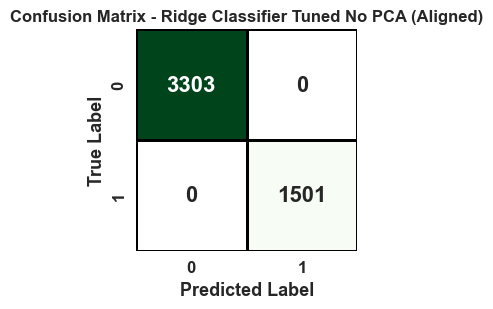

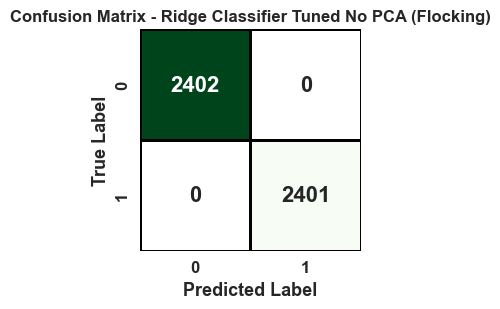

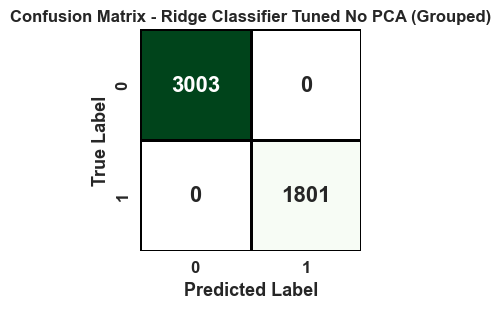

In [180]:
# Creating green/silver confusion matrices for the selected final model on each test set

for _, row in final_model_rows.iterrows():
    dataset_name = row["Dataset"]
    X_train, X_test, y_train, y_test = final_dataset_splits[dataset_name]

    # Rebuilding the selected final model
    model = clone(tuned_model_configs[final_model_name]["model"])
    best_params = parse_best_params(row["Best Parameters"])
    model.set_params(**best_params)

    # Fitting and predicting
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    diag_mask = ~np.eye(cm.shape[0], dtype=bool)
    off_diag_mask = np.eye(cm.shape[0], dtype=bool)

    plt.figure(figsize=(3.5, 3.2))

    # Correct predictions: green diagonal cells
    sns.heatmap(
        cm,
        mask=diag_mask,
        annot=True,
        fmt="d",
        cmap="Greens",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="black",
        annot_kws={"size": 16, "weight": "bold"}
    )

    # Incorrect predictions: gray/silver off-diagonal cells
    sns.heatmap(
        cm,
        mask=off_diag_mask,
        annot=True,
        fmt="d",
        cmap="Greys",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="black",
        annot_kws={"size": 16, "weight": "bold"}
    )

    plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
    plt.ylabel("True Label", fontsize=13, fontweight="bold")
    plt.title(
        f"Confusion Matrix - {final_algorithm} {final_model_version} ({dataset_name})",
        fontsize=12,
        fontweight="bold"
    )

    plt.xticks(fontsize=12, fontweight="bold")
    plt.yticks(fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

This cell creates ROC curves for the final model.

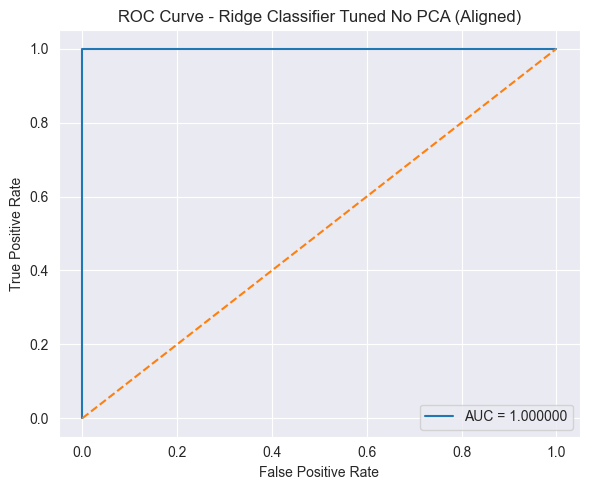

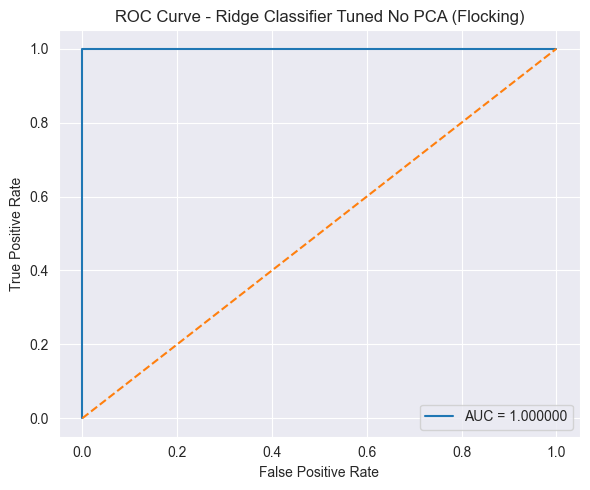

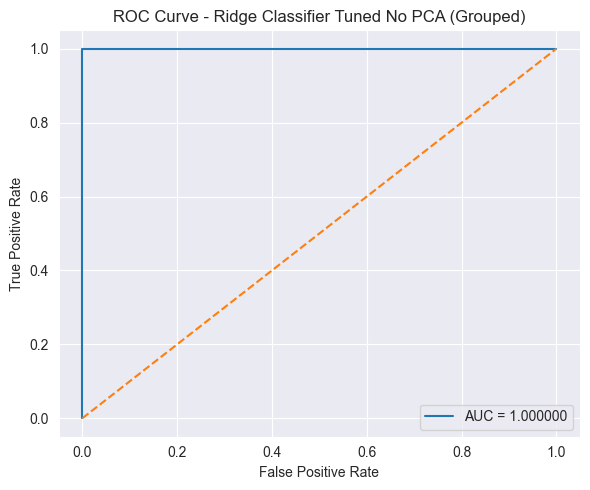

In [166]:
# Creating ROC curves for the selected final model

for _, row in final_model_rows.iterrows():
    dataset_name = row["Dataset"]
    X_train, X_test, y_train, y_test = final_dataset_splits[dataset_name]

    # Rebuilding the selected final model
    model = clone(tuned_model_configs[final_model_name]["model"])
    best_params = parse_best_params(row["Best Parameters"])
    model.set_params(**best_params)

    # Fitting on full training set
    model.fit(X_train, y_train)

    # Getting decision scores for ROC curve
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError(f"{final_model_name} does not support decision_function or predict_proba.")

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.6f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {final_algorithm} {final_model_version} ({dataset_name})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

This cell creates a bar chart comparing the average test F1-score across all tuned model strategies. Since F1-score was the primary model selection metric, this chart helps visualize how closely the tuned models performed on unseen test data.

,Model Label,Average_Test_F1
0,Ridge Classifier - Tuned PCA(10),0.945831
1,Ridge Classifier - Tuned SelectKBest(200),0.972898
2,Ridge Classifier - Tuned PCA(20),0.985233
3,Ridge Classifier - Tuned PCA(30),0.987283
4,Ridge Classifier - Tuned PCA(40),0.987962
5,Ridge Classifier - Tuned PCA(50),0.989800
6,Logistic Regression - Tuned SelectKBest(200),0.994661
7,Linear SVC - Tuned SelectKBest(200),0.995064
8,Linear SVC - Tuned PCA(10),0.997059
9,Logistic Regression - Tuned PCA(10),0.997432


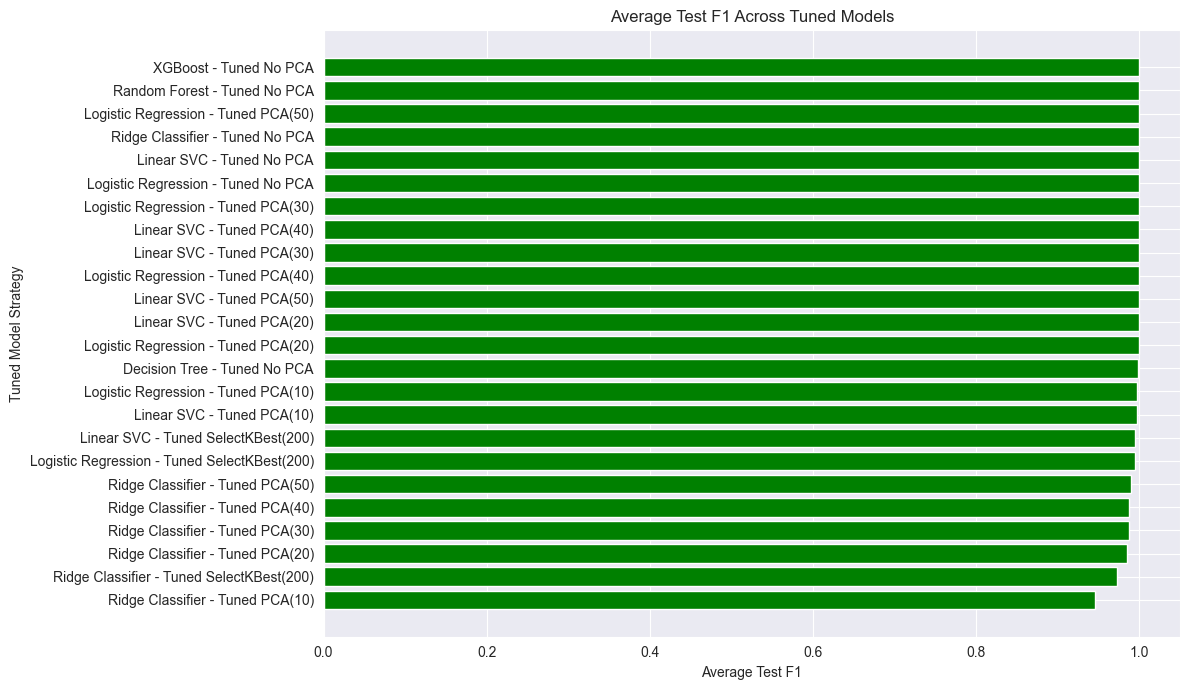

In [159]:
# Bar Chart: Average Test F1 Across Tuned Models
# Horizontal green bar chart

f1_chart_df = average_train_test_results_df.copy()

f1_chart_df["Model Label"] = (
    f1_chart_df["Algorithm"] + " - " + f1_chart_df["Model Version"]
)

f1_chart_df = f1_chart_df.sort_values(
    by="Average_Test_F1",
    ascending=True
).reset_index(drop=True)

display(f1_chart_df[["Model Label", "Average_Test_F1"]])

plt.figure(figsize=(12, 7))
plt.barh(f1_chart_df["Model Label"], f1_chart_df["Average_Test_F1"], color="green")
plt.xlabel("Average Test F1")
plt.ylabel("Tuned Model Strategy")
plt.title("Average Test F1 Across Tuned Models")
plt.tight_layout()
plt.show()

This cell creates a bar chart comparing the average final test prediction time across all tuned model strategies. Prediction time was one of the tie-breakers for final model selection, so this chart helps compare inference efficiency across models.

,Model Label,Average_Final_Test_Predict_Time_sec
0,Logistic Regression - Tuned SelectKBest(200),0.066260
1,Ridge Classifier - Tuned SelectKBest(200),0.067649
2,Decision Tree - Tuned No PCA,0.068500
3,Linear SVC - Tuned SelectKBest(200),0.070748
4,Linear SVC - Tuned PCA(20),0.125038
5,Ridge Classifier - Tuned No PCA,0.125760
6,Logistic Regression - Tuned PCA(10),0.126356
7,Logistic Regression - Tuned PCA(30),0.126637
8,Logistic Regression - Tuned PCA(50),0.127542
9,Logistic Regression - Tuned PCA(20),0.128163


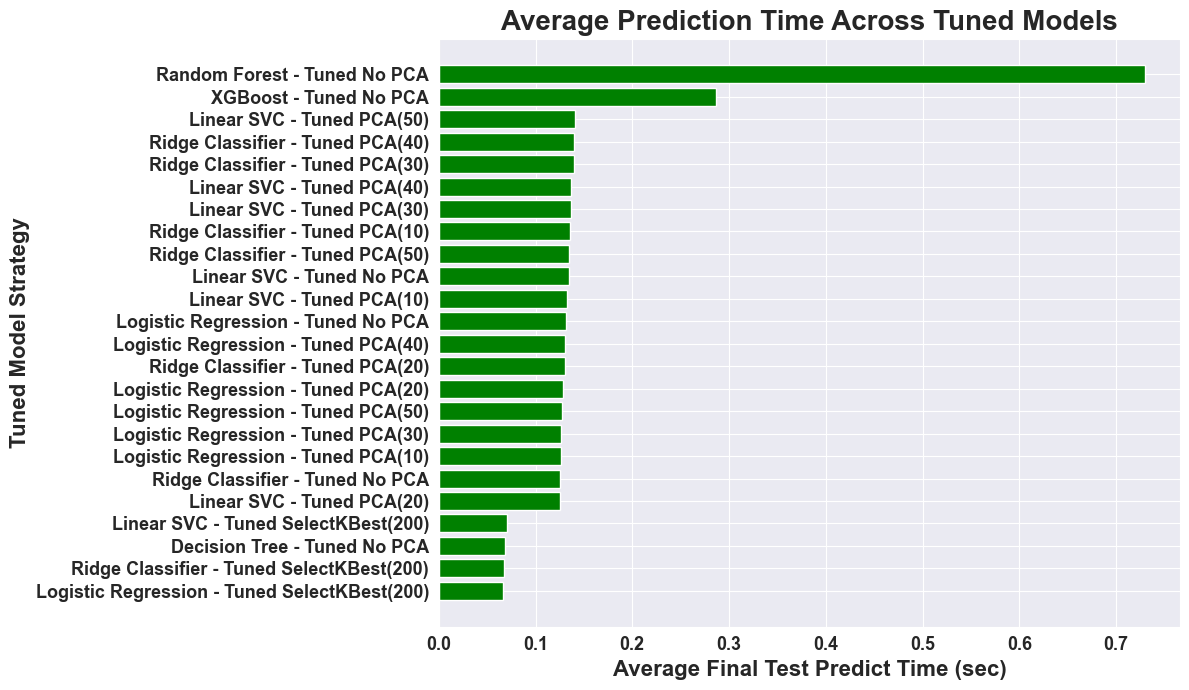

In [174]:
# Bar Chart: Average Prediction Time Across Tuned Models
# Horizontal green bar chart

predict_time_chart_df = average_train_test_results_df.copy()

predict_time_chart_df["Model Label"] = (
    predict_time_chart_df["Algorithm"] + " - " + predict_time_chart_df["Model Version"]
)

predict_time_chart_df = predict_time_chart_df.sort_values(
    by="Average_Final_Test_Predict_Time_sec",
    ascending=True
).reset_index(drop=True)

display(predict_time_chart_df[["Model Label", "Average_Final_Test_Predict_Time_sec"]])

plt.figure(figsize=(12, 7))
plt.barh(
    predict_time_chart_df["Model Label"],
    predict_time_chart_df["Average_Final_Test_Predict_Time_sec"],
    color="green"
)

plt.xlabel("Average Final Test Predict Time (sec)", fontsize=16, fontweight="bold")
plt.ylabel("Tuned Model Strategy", fontsize=16, fontweight="bold")
plt.title(
    "Average Prediction Time Across Tuned Models",
    fontsize=20,
    fontweight="bold"
)

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

Prediction with best model!

In [162]:
# Creating prediction examples for the selected final model

prediction_examples = []

for dataset_name, (X_train, X_test, y_train, y_test) in final_dataset_splits.items():

    # Getting the best parameter row for this dataset and selected final model
    model_row = final_model_rows[final_model_rows["Dataset"] == dataset_name].iloc[0]

    # Rebuilding and fitting the selected final model
    model = clone(tuned_model_configs[final_model_name]["model"])
    model.set_params(**parse_best_params(model_row["Best Parameters"]))
    model.fit(X_train, y_train)

    # Randomly selecting 3 unseen test examples
    sample_X = X_test.sample(n=3, random_state=42)
    sample_y = y_test.loc[sample_X.index]

    # Predicting one row at a time so each prediction has its own timing
    for sample_index in sample_X.index:
        single_sample = sample_X.loc[[sample_index]]

        prediction_start_time = time.time()
        predicted_class = model.predict(single_sample)[0]
        prediction_end_time = time.time()

        actual_class = sample_y.loc[sample_index]

        prediction_examples.append({
            "Dataset": dataset_name,
            "Algorithm": final_algorithm,
            "Model Version": final_model_version,
            "Sample Index": sample_index,
            "Actual Class": actual_class,
            "Predicted Class": predicted_class,
            "Correct Prediction": actual_class == predicted_class,
            "Prediction Time (sec)": prediction_end_time - prediction_start_time
        })

# Creating prediction examples DataFrame
prediction_examples_df = pd.DataFrame(prediction_examples)

display(prediction_examples_df)

,Dataset,Algorithm,Model Version,Sample Index,Actual Class,Predicted Class,Correct Prediction,Prediction Time (sec)
0,Aligned,Ridge Classifier,Tuned No PCA,3336,0,0,True,0.010510
1,Aligned,Ridge Classifier,Tuned No PCA,13430,0,0,True,0.010001
2,Aligned,Ridge Classifier,Tuned No PCA,5390,0,0,True,0.009000
3,Flocking,Ridge Classifier,Tuned No PCA,8514,1,1,True,0.008999
4,Flocking,Ridge Classifier,Tuned No PCA,20191,1,1,True,0.009006
5,Flocking,Ridge Classifier,Tuned No PCA,6715,0,0,True,0.007998
6,Grouped,Ridge Classifier,Tuned No PCA,17685,1,1,True,0.009003
7,Grouped,Ridge Classifier,Tuned No PCA,14852,0,0,True,0.007998
8,Grouped,Ridge Classifier,Tuned No PCA,17784,0,0,True,0.008507


Comparing tuned vs untuned final model

In [163]:
# Comparing selected final model against its baseline version

# Getting baseline averages for the selected algorithm
baseline_avg = baseline_results_df[
    baseline_results_df["Model"] == final_algorithm
].agg({
    "Baseline Accuracy": "mean",
    "Baseline F1": "mean",
    "Baseline ROC-AUC": "mean",
    "Average Predict Time (sec)": "mean",
    "Average Fit Time (sec)": "mean"
})

# Getting final tuned averages for the selected model
final_avg = average_train_test_results_df[
    (average_train_test_results_df["Algorithm"] == final_algorithm) &
    (average_train_test_results_df["Model Version"] == final_model_version)
].iloc[0]

# Creating comparison table
baseline_vs_final_df = pd.DataFrame([
    {
        "Algorithm": final_algorithm,
        "Model Version": "Baseline",
        "Accuracy": baseline_avg["Baseline Accuracy"],
        "F1": baseline_avg["Baseline F1"],
        "ROC-AUC": baseline_avg["Baseline ROC-AUC"],
        "Predict Time (sec)": baseline_avg["Average Predict Time (sec)"],
        "Fit Time (sec)": baseline_avg["Average Fit Time (sec)"]
    },
    {
        "Algorithm": final_algorithm,
        "Model Version": final_model_version,
        "Accuracy": final_avg["Average_Test_Accuracy"],
        "F1": final_avg["Average_Test_F1"],
        "ROC-AUC": final_avg["Average_Test_ROC_AUC"],
        "Predict Time (sec)": final_avg["Average_Final_Test_Predict_Time_sec"],
        "Fit Time (sec)": final_avg["Average_Final_Fit_Time_sec"]
    }
])

display(baseline_vs_final_df)

,Algorithm,Model Version,Accuracy,F1,ROC-AUC,Predict Time (sec),Fit Time (sec)
0,Ridge Classifier,Baseline,0.999809,0.999771,0.99997,0.163422,1.543360
1,Ridge Classifier,Tuned No PCA,1.000000,1.000000,1.00000,0.125760,2.081272


Prediction Time/F1 charts of final model vs baseline model

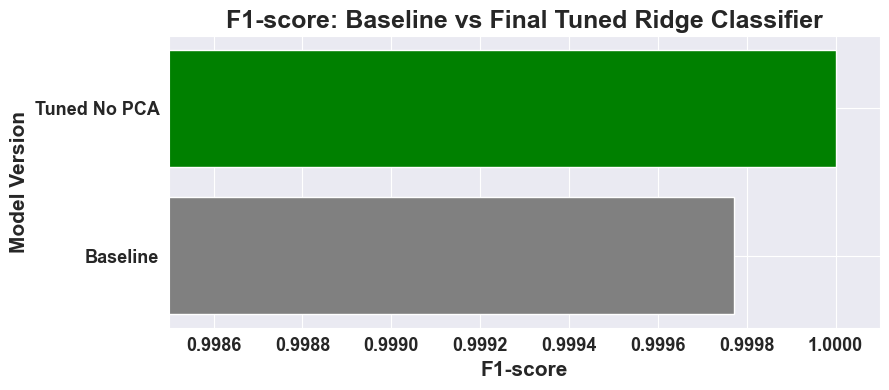

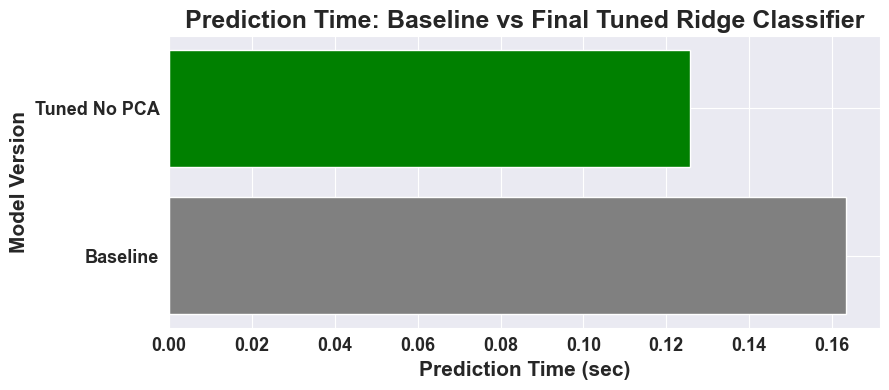

In [176]:
plot_df = baseline_vs_final_df.copy()

# F1-score comparison - horizontal
plt.figure(figsize=(9, 4))
plt.barh(
    plot_df["Model Version"],
    plot_df["F1"],
    color=["gray", "green"]
)
plt.xlabel("F1-score", fontsize=15, fontweight="bold")
plt.ylabel("Model Version", fontsize=15, fontweight="bold")
plt.title(
    f"F1-score: Baseline vs Final Tuned {final_algorithm}",
    fontsize=18,
    fontweight="bold"
)
plt.xlim(0.9985, 1.0001)
plt.ticklabel_format(style="plain", axis="x")
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# Prediction time comparison - horizontal
plt.figure(figsize=(9, 4))
plt.barh(
    plot_df["Model Version"],
    plot_df["Predict Time (sec)"],
    color=["gray", "green"]
)
plt.xlabel("Prediction Time (sec)", fontsize=15, fontweight="bold")
plt.ylabel("Model Version", fontsize=15, fontweight="bold")
plt.title(
    f"Prediction Time: Baseline vs Final Tuned {final_algorithm}",
    fontsize=18,
    fontweight="bold"
)
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Conclusion:
The Swarm Behaviour datasets were highly separable, which was supported by the EDA, PCA analysis, baseline models, tuned models, confusion matrices, and ROC curves. Most models achieved near-perfect performance, showing that the feature space contained strong predictive signal for distinguishing the two classes.

Light hyperparameter tuning confirmed that several models could classify the data extremely well, but it did not produce a major performance gap because the baseline models were already highly accurate. Since many models reached near-perfect F1-score and ROC-AUC, prediction time became an important factor in selecting the final model.

The final selected model achieved near-perfect classification performance while also producing the fastest average prediction time among the eligible models. This made it the best practical choice for this project. Overall, the results show that when a dataset is highly separable, the best model is not always the most complex model; it is the model that maintains excellent predictive performance while also being efficient.